# Fitting Donor-Acceptor FLIM Data

The donor **and** acceptor fluorescence decay profiles is to be described and fitted for determination of the resonance energy transfer rate.

$$\frac{d[D^*]}{dt} = - \frac{d[D]}{dt} = -(k_{f}^{D} + k_{r}^{DA})D^* + \phi^{D} \text{IRF}(t)$$

$$\frac{d[A^*]}{dt} = - \frac{d[A]}{dt} = -k_{f}^{A} A^* + k_{r}^{DA})D^* + \lambda^{DA} \bigg[ \frac{d[D^*]}{dt} (t) \bigg] + \phi^{A} \text{IRF}(t)$$

In the system of differential equations, the change in the population of excited and ground state donor and acceptor molecules is described.

Both molecules are assumed to decay from their excited state, $D^*$ and $A^*$, with the rate constants $k_{f}^{D}$ and $k_{f}^{A}$, respectively (i.e. monoexponentially). The energy transfer takes places between the excited donor molecule population, $[D^*]$, and thus excited molecules from the ground state acceptor population, $[A]$, with the rate constant $k_{r}^{DA}$ (superscript denotes direction of energy transfer from left to right). The ground state acceptor population is not included in the description of the acceptor population, because it is assumed that $[A] \gg [D^*]$.

The donor is excited via laser excitation, which is described by the instrument response function of the measurement setup, $\text{IRF}(t)$. It can be either approximted as a Gaussian or fitted to measured data and fitted to a multi-component Gaussian function. For testing and simulation purposes, $\tetx{IRF}(t)$ is modeled as
Gaussian function

$$\text{IRF}(t) = \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{1}{2} \big( \frac{t - \mu_{i}}{\sigma} \big)^{2}}$$

with the $\text{FWHM}$ of the $\text{IRF}$ as $2 \sqrt{2 \ ln 2} \ \sigma \approx 2.3548 \sigma$. 

The purpose of the model is to include two main error inherent to simultanous donor-acceptor measurement, either via FLIM or intensity-based: 1.) excitation of the acceptor by the laser at donor excitation wavelength ($\phi^{A}$) and 2.) bleed-through of the donor signal into the acceptor detection channel ($\lambda^{DA}$).
The cross-excitation is modeled as a fractional contribution of $\text{IRF}(t)$ to the excitation of $[A]$. This is determined by a sample, where only the acceptor molecule is expressed and it is excited at the donor wavelength. The spectral bleed-through, $\lambda^{DA}$, of the donor signal into the acceptor detection channel is modeled as a fractional addition of the current donor signal at $t$ to the acceptor signal at $t$ weighted by a constant. 


Furthermore, maximum likelihood estimation is employed for estimation of the systems parameters (see Bajzer et al., 1991)...

In [191]:
%reset -f
# Importing required modules and setting up matplotlib
import math
import struct
import io
from numba import jit
from scipy.integrate import odeint
import scipy.optimize as optimize
import numpy as np
import matplotlib.pyplot as plt


from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

# Import PTU reading / decoding functions
import pq_decoding_functions

In [312]:

def da_flim_ODE(y, t, pars):
    
    kf_D, k_r, kf_A, sigma, mu = pars
    t = t
        
    
    dD1 = -(1/kf_D)*y[1] - (1/k_r)*y[1] + gauss_laser(t, mu, sigma)*y[0]
    dD0= -dD1
    dA1 = -(1/kf_A)*y[3] + (1/k_r)*y[1]# + 
    dA0 = -dA1
    return([dD0, dD1, dA0, dA1])



def eval_ode(t, pars, fitting = False):
    y0 = pars[0:4]
    sim_params = pars[4:9]
    offset_donor = pars[9]
    offset_acceptor = pars[10]
    acceptor_shift = pars[11]
    btDA = pars[12]
    
    sol = odeint(da_flim_ODE, y0, t, hmax = dt, args = (sim_params, ))
    
    
    # Adding spectral bleed-through of donor signal into acceptor detection channel
    sol = addSpectralBleedthrough(sol, btDA) 
    
    # Displacing excited acceptor signal to simulate difference
    # in photon arrival time, e.g. due to different cable
    # lenghts to acceptor signal detector.
    # np.roll() wraps array around itself.
    t_step = t[1] - t[0]
    sol[:, 3] = np.roll(sol[:, 3], int(acceptor_shift / t_step))
    
    # fitting: bool indicates whether curve fitting is performed or data is simulated
    # When data is fitted, we don't need to add noise, but want to add an offset.
    # When data is simulated, addPoissonNoise() adds intensity-weighted Poisson noise and
    # an additional Poisson noise array to each decay with lambda = offset
    if(fitting):
        sol[:, 1] += offset_donor
        sol[:, 3] += offset_acceptor
        
    else:
        sol = addPoissonNoise(sol, offset_donor, offset_acceptor)
    
    return(sol)

@jit(nopython = True)
def gauss_laser(t, mu, sigma):
    out = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((t - mu) / sigma)**2)
    return(float(out))



def addPoissonNoise(decay, offset_donor, offset_acceptor):
    decay[:, 1] = np.random.poisson(decay[:, 1], len(decay[:, 1])) # Only adding to excited donor decay at index 1
    decay[:, 1] += np.random.poisson(offset_donor, len(decay[:, 1]))
    decay[:, 3] = np.random.poisson(decay[:, 3], len(decay[:, 3])) # Only adding to excited donor decay at index 1
    decay[:, 3] += np.random.poisson(offset_acceptor, len(decay[:, 3])) # Only adding to excited acceptor decay at index 3
    return(decay)

def addSpectralBleedthrough(decay, bleedthrough = 0):
    decay[:, 3] += decay[:, 1] / bleedthrough
    return(decay)



def estimateBackground(data):
    '''
        Calculates median of last 7 % of data.
        Used for weighting of 0 values; would otherwise lead to division by 0. Instead,
        the weight for the median background value is used for residue weighting.
    '''
    index_right_cutoff = int(math.floor(len(data) * 0.97))
    index_left_cutoff = int(math.floor(len(data) * 0.90))
    background = np.mean(data[index_left_cutoff : index_right_cutoff]) # Mean oder Median?
    
    
    return(background)


def calculateWeights(data):
    weights = np.zeros_like(data)
    weights = 1.0/np.sqrt(data, where = (data != 0))
    
    # n
    weights[np.where(data == 0)] = 1.0/np.sqrt(estimateBackground(data))

    return(weights)


def residuals(pars, t, data, weighted = True):
    model = eval_ode(t, pars, fitting = True)

    if(weighted == True):
        
        resids_donor = (((data[:, 1] - model[:, 1])**2) * calculateWeights(data[:, 1])) / model[:, 1]
        resids_acceptor = (((data[:, 3] - model[:, 3])**2) * calculateWeights(data[:, 3])) / model[:, 3]
        
    else:
        resids_donor = ((data[:, 1] - model[:, 1])**2) / model[:, 1]
        resids_acceptor = ((data[:, 3] - model[:, 3])**2) / model[:, 3]
    
    resids = np.hstack((resids_donor, resids_acceptor))
    resids = np.sum(resids)
   
    return(resids)


## Get left flank of decays for time offset determination --> required for proper time offset guessing
## Returns index at which left decay flank
def get_decay_flank(decay):
    first_derivative = np.diff(decay, n = 1)
    max_rise = np.where(first_derivative == max(first_derivative))[0][0]
    
    return(max_rise)



# Manually calculating chi-squared for donor and acceptor each
def calculate_chi_squred(data, fit, number_fit_parameters = 11):
    donor_resids = np.sum(
        (data[:, 1] - fit[:, 1])**2 / fit[:, 1]
    )
    acceptor_resids = np.sum(
        (data[:, 3] - fit[:, 3])**2 / fit[:, 3]
    )
    
    red_chi_donor = donor_resids / (len(data[:, 1]) - number_fit_parameters - 1)
    red_chi_acceptor = acceptor_resids / (len(data[:, 3]) - number_fit_parameters - 1)
    
    return([red_chi_donor, red_chi_acceptor])

In [430]:
# Setting up the simulation time axis and simulation parameters
tStart = 0
tEnd = 51000
dt = 16
tSteps = int((tEnd - tStart) / dt)
t = np.linspace(tStart, tEnd, tSteps)

sim_params = np.array((
    800, # D(0)
    0.1, # D*(0)
    0, # A(0)
    0, # A*(0)
    2500, #kf_D in ps
    200000, #k_r in ps
    2000, #kf_A in ps
    150, #sigma in ps
    5000, #mu in ps
    1, #offset_donor in y
    1, # offset_acceptor in y
    -100, #acceptor_shift
    150 # btDA spectral bleed-through of donor signal into acceptor channel
))

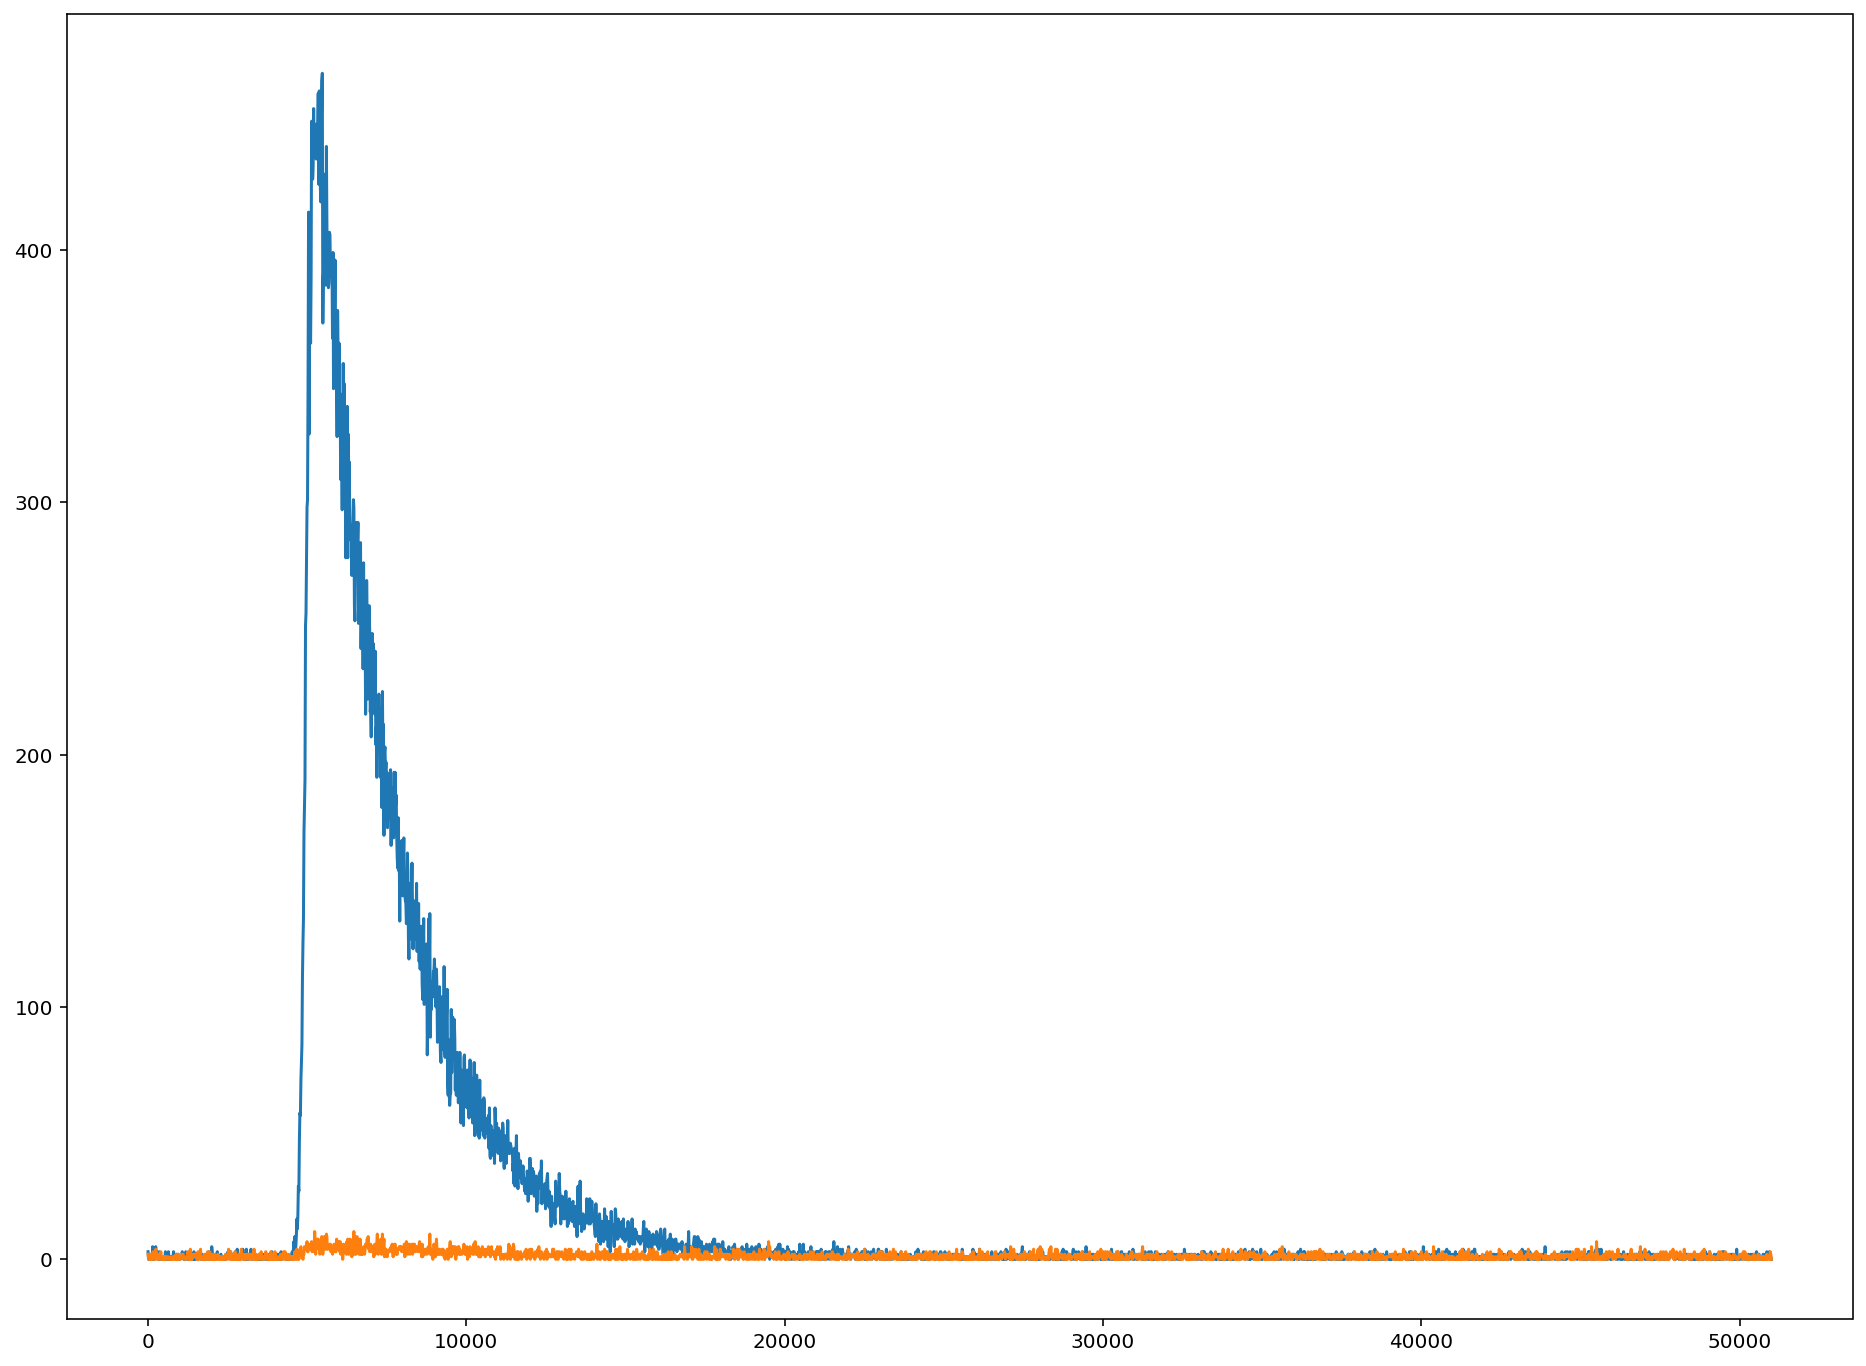

In [431]:
# Calculating example data and adding noise

sim_data = eval_ode(t, sim_params, fitting = False) # Fitting set to False, so that Poisson noise is addded


plt.plot(t, sim_data[:, 1])
plt.plot(t, sim_data[:, 3])
plt.yscale('linear')
plt.show()

In [432]:
## Defining lmfit.Parameters object for curve fitting

#guessed_mu = get_decay_flank(sim_data[:, 1])
#guessed_acceptor_shift = guessed_mu - get_decay_flank(sim_data[:, 3])


# Fitting parameters for scipy.optimize + fit bounds+

#para_start = (
#    500, # D(0) -> Number of ground state molecules at t = 0
#    0.1, # D*(0)
#    500, # A(0)
#    0.1, # A*(0)
#    2400, # kf_D -> Donor decay rate/
#    4000, # k_r -> Rate of energy transfer
#    1400, # kf_A -> Acceptor decay rate
#    80, # sigma -> Width of excitation pulse
#    5000, # mu -> t-offset of excitation pulse
#    10, # offset_donor -> y-offset of donor decay
#    10, # offset_acceptor -> y-offset of acceptor decay
#    -200, # acceptor_shift -> in ps
#    50 # btDA -> spectral bleed-through of donor into acceptor channel
#)



#para_scale = (
#    1,
#    1, 
#    1, 
#    1,
#    0.5,
#    0.25,
#    0.5,
#    1,
#    1,
#    1,
#    1,
#    0.01,
#    0.01
#)

#para_bounds = (
#    # Lower bounds
#    (1, # D(0),
#     0, # D*(0)
#     1, # A(0)
#     0, # A*(0)
#     1000, # kf_D
#     1000, # k_r
#     1000, # kf_A
#     40, # sigma
#     3400, # mu
#     0, # offset_donor
#     0, # offset_acceptor
#     0), # acceptor_shift
#    # Upper bounds
#    (10000,
#     1,
#     10000,
#     1,
#     3000,
#     100000,
#     4000,
#     200,
#    7000,
#    100,
#     100, 
#     1)
#)

In [433]:
#fit = optimize.least_squares(
#    residuals,
#    para_start,
#    method = 'trf',
#    loss = 'huber',
#    args = (t, sim_data, False), # Arguments passed to residuals(); True refers to weighted
#    bounds = para_bounds,
#    x_scale = para_scale,
#    #ftol = 1e-15,
#    #xtol = 1e-15,
#    verbose = 1
#)

In [434]:
# Fitting by minimizing least-squares

#para_start = (
#    500, # D(0) -> Number of ground state molecules at t = 0
#    0, # D*(0)
#    10, # A(0)
#    0, # A*(0)
#    2500, # kf_D -> Donor decay rate/
#    4000, # k_r -> Rate of energy transfer
#    2000, # kf_A -> Acceptor decay rate
#    80, # sigma -> Width of excitation pulse
#    5000, # mu -> t-offset of excitation pulse
#    10, # offset_donor -> y-offset of donor decay
#    10, # offset_acceptor -> y-offset of acceptor decay
#    0 # acceptor_shift -> in ps
#)



#para_bounds = (
#    (1, 10000), # D1
#    (0, 0.1), # D0
#    (1, 10000), # A1
#    (0, 0.1), # A0
#    (1500, 5000), # kf_D
#    (1000, 100000), # k_r
#    (1000, 5000), # kf_A
#    (30, 200), # IRF sigma
#    (3000, 8000), # IRF mu
#    (0, 100), # offset_donor
#    (0, 100), # offset_acceptor
#    (-2000, 6000) # acceptor shift
#)
#fit = optimize.minimize(
#    residuals,
#    para_start,
#    args = (t, sim_data, True),
#    method = 'SLSQP',
#    bounds = para_bounds,
#    options = {
#        'ftol': 1e-5,
#        'eps': 10
#    }
#)

In [438]:
# Fitting by maximum likelihood estimator (originally for fitting reconvolutional model)#
def residuals(pars, t, data):
    
    stacked_data = np.hstack([
        data[:, 1],
        data[:, 3]
    ])
    
    fitted = eval_ode(t, pars, fitting = True)
    stacked_fitted = np.hstack([
        fitted[:, 1],
        fitted[:, 3]
    ])
    
    deviance = 2 * np.nansum(
            stacked_data * np.log(stacked_data / stacked_fitted) - (stacked_data - stacked_fitted)
    )
    
    MLE_estimator = np.nansum(deviance)
    
    return(MLE_estimator)


sim_params = np.array((
    800, # D(0)
    0.1, # D*(0)
    0, # A(0)
    0, # A*(0)
    2500, #kf_D in ps
    200000, #k_r in ps
    2000, #kf_A in ps
    150, #sigma in ps
    5000, #mu in ps
    1, #offset_donor in y
    1, # offset_acceptor in y
    -100, #acceptor_shift
    150 # btDA spectral bleed-through of donor signal into acceptor channel
))

sim_data = eval_ode(t, sim_params, fitting = False)

para_start = (
    1000, # D(0) -> Number of ground state molecules at t = 0
    0, # D*(0)
    0, # A(0)
    0, # A*(0)
    2500, # kf_D -> Donor decay rate/
    10000, # k_r -> Rate of energy transfer
    2000, # kf_A -> Acceptor decay rate
    80, # sigma -> Width of excitation pulse
    5000, # mu -> t-offset of excitation pulse
    10, # offset_donor -> y-offset of donor decay
    10, # offset_acceptor -> y-offset of acceptor decay
    -100, # acceptor_shift -> in ps
    10 # btDA -> spectral bleed-through of donor into acceptor channel
)

para_names = (
    "D(0)",
    "D*(0)",
    "A(0)",
    "A*(0)",
    "kf_D",
    "k_r",
    "kf_A",
    "sigma",
    "mu",
    "offD",
    "offA",
    "as",
    "btDA"
)

para_bounds = (
    (1, 10000), # D1
    (0, 0.1), # D0
    (1, 10000), # A1
    (0, 0.1), # A0
    (2480, 2520), # kf_D
    (1000, 100000), # k_r
    (1000, 2020), # kf_A
    (30, 200), # IRF sigma
    (3000, 8000), # IRF mu
    (0, 100), # offset_donor
    (0, 100), # offset_acceptor
    (-2000, 6000), # acceptor shift
    (1, 200) #  btDA
)
fit = optimize.minimize(
    residuals,
    para_start,
    args = (t, sim_data),
    method = 'SLSQP',
    bounds = para_bounds,
    options = {
        #'ftol': 1e-5,
        'eps': 0.1,
        'disp': True
    }
)

/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: divide by zero encountered in log
  app.launch_new_instance()
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in multiply
  app.launch_new_instance()
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: divide by zero encountered in true_divide
  app.launch_new_instance()
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: overflow encountered in true_divide
  app.launch_new_instance()
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in true_divide
  app.launch_new_instance()
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in log
  app.launch_new_instance()


Optimization terminated successfully.    (Exit mode 0)
            Current function value: 2610.1535531331874
            Iterations: 61
            Function evaluations: 968
            Gradient evaluations: 61


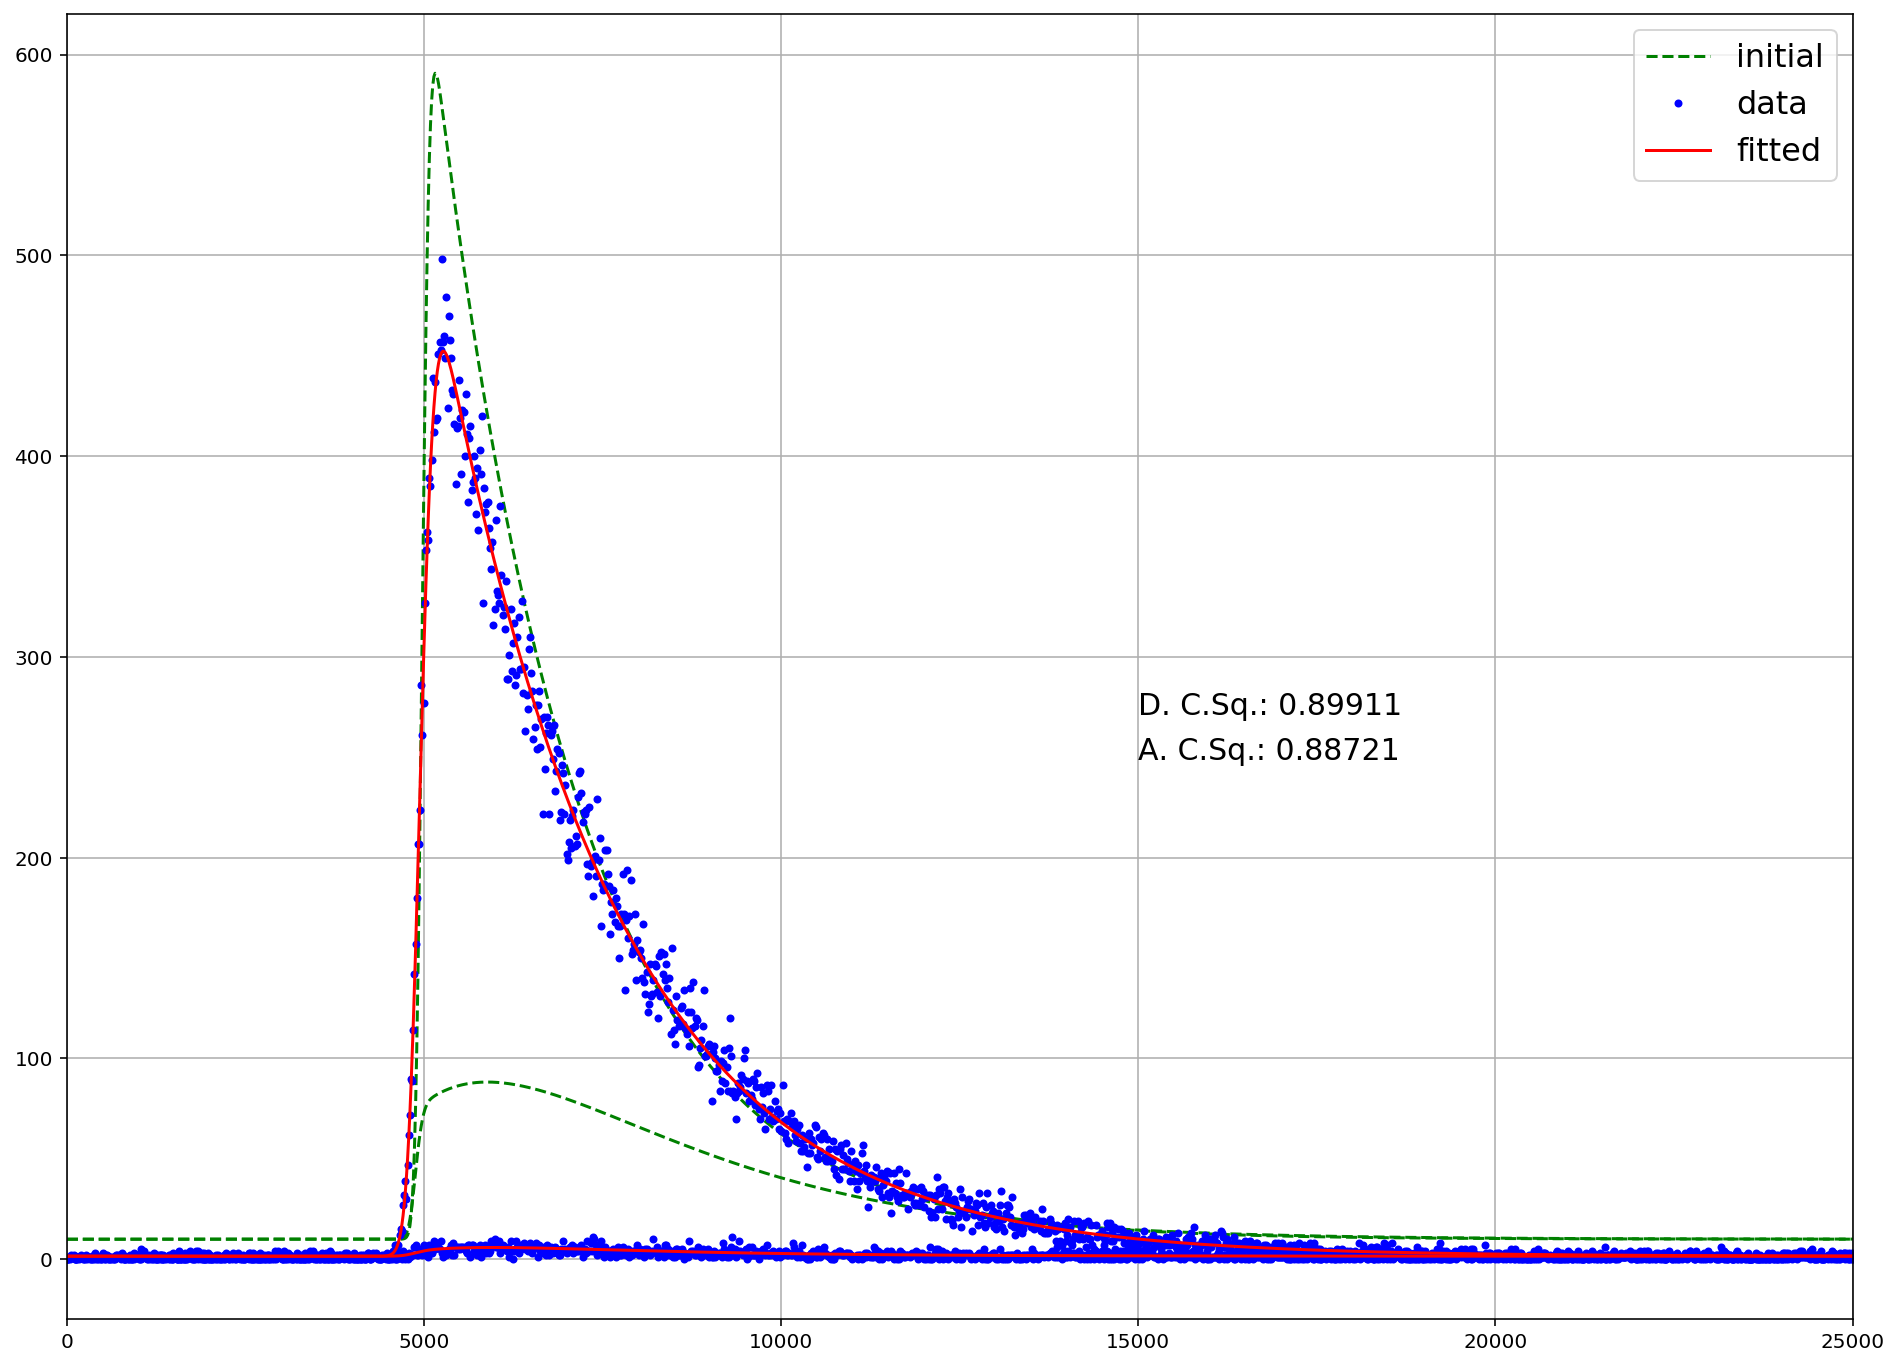

In [439]:
initial_guess = eval_ode(t, para_start, fitting = True)
fitted = eval_ode(t, fit.x, fitting = True)

# Getting red. chi-squared values for both curves
red_chi = calculate_chi_squred(
    data = sim_data,
    fit = fitted,
    number_fit_parameters = len(para_start)
)

plt.plot(t, initial_guess[:, 1],  'g--', label = 'initial')
plt.plot(t, initial_guess[:, 3],  'g--', )
plt.plot(t, sim_data[:, 1],  'b.', label = 'data')
plt.plot(t, sim_data[:, 3],  'b.')
plt.plot(t, fitted[:, 1],  'r-', label = 'fitted')
plt.plot(t, fitted[:, 3],  'r-')
plt.xlim(0, 25000)
plt.yscale('linear')
plt.legend(loc = 'best')
plt.grid()
plt.text(15000, 0.6 * np.max(fitted[:, 1]),
        s = 'D. C.Sq.: ' + str(round(red_chi[0], 5)),
        fontsize = 15 
)
plt.text(15000, 0.55 * np.max(fitted[:, 1]),
        s = 'A. C.Sq.: ' + str(round(red_chi[1], 5)),
        fontsize = 15 
)
plt.show()

In [440]:
print("\tInput Parameters\t Fitted Parameters")
print("-----------------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", round(sim_params[i], 6), "\t\t", round(fit['x'][i], 6))

	Input Parameters	 Fitted Parameters
-----------------------------------------------------
D(0) 		 800.0 		 804.774573
D*(0) 		 0.1 		 0.1
A(0) 		 0.0 		 1.073939
A*(0) 		 0.0 		 0.0
kf_D 		 2500.0 		 2501.061632
k_r 		 200000.0 		 100000.0
kf_A 		 2000.0 		 1000.0
sigma 		 150.0 		 150.649337
mu 		 5000.0 		 4999.048612
offD 		 1.0 		 1.48949
offA 		 1.0 		 1.524344
as 		 -100.0 		 -100.0
btDA 		 150.0 		 200.0


/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: divide by zero encountered in true_divide
  
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.


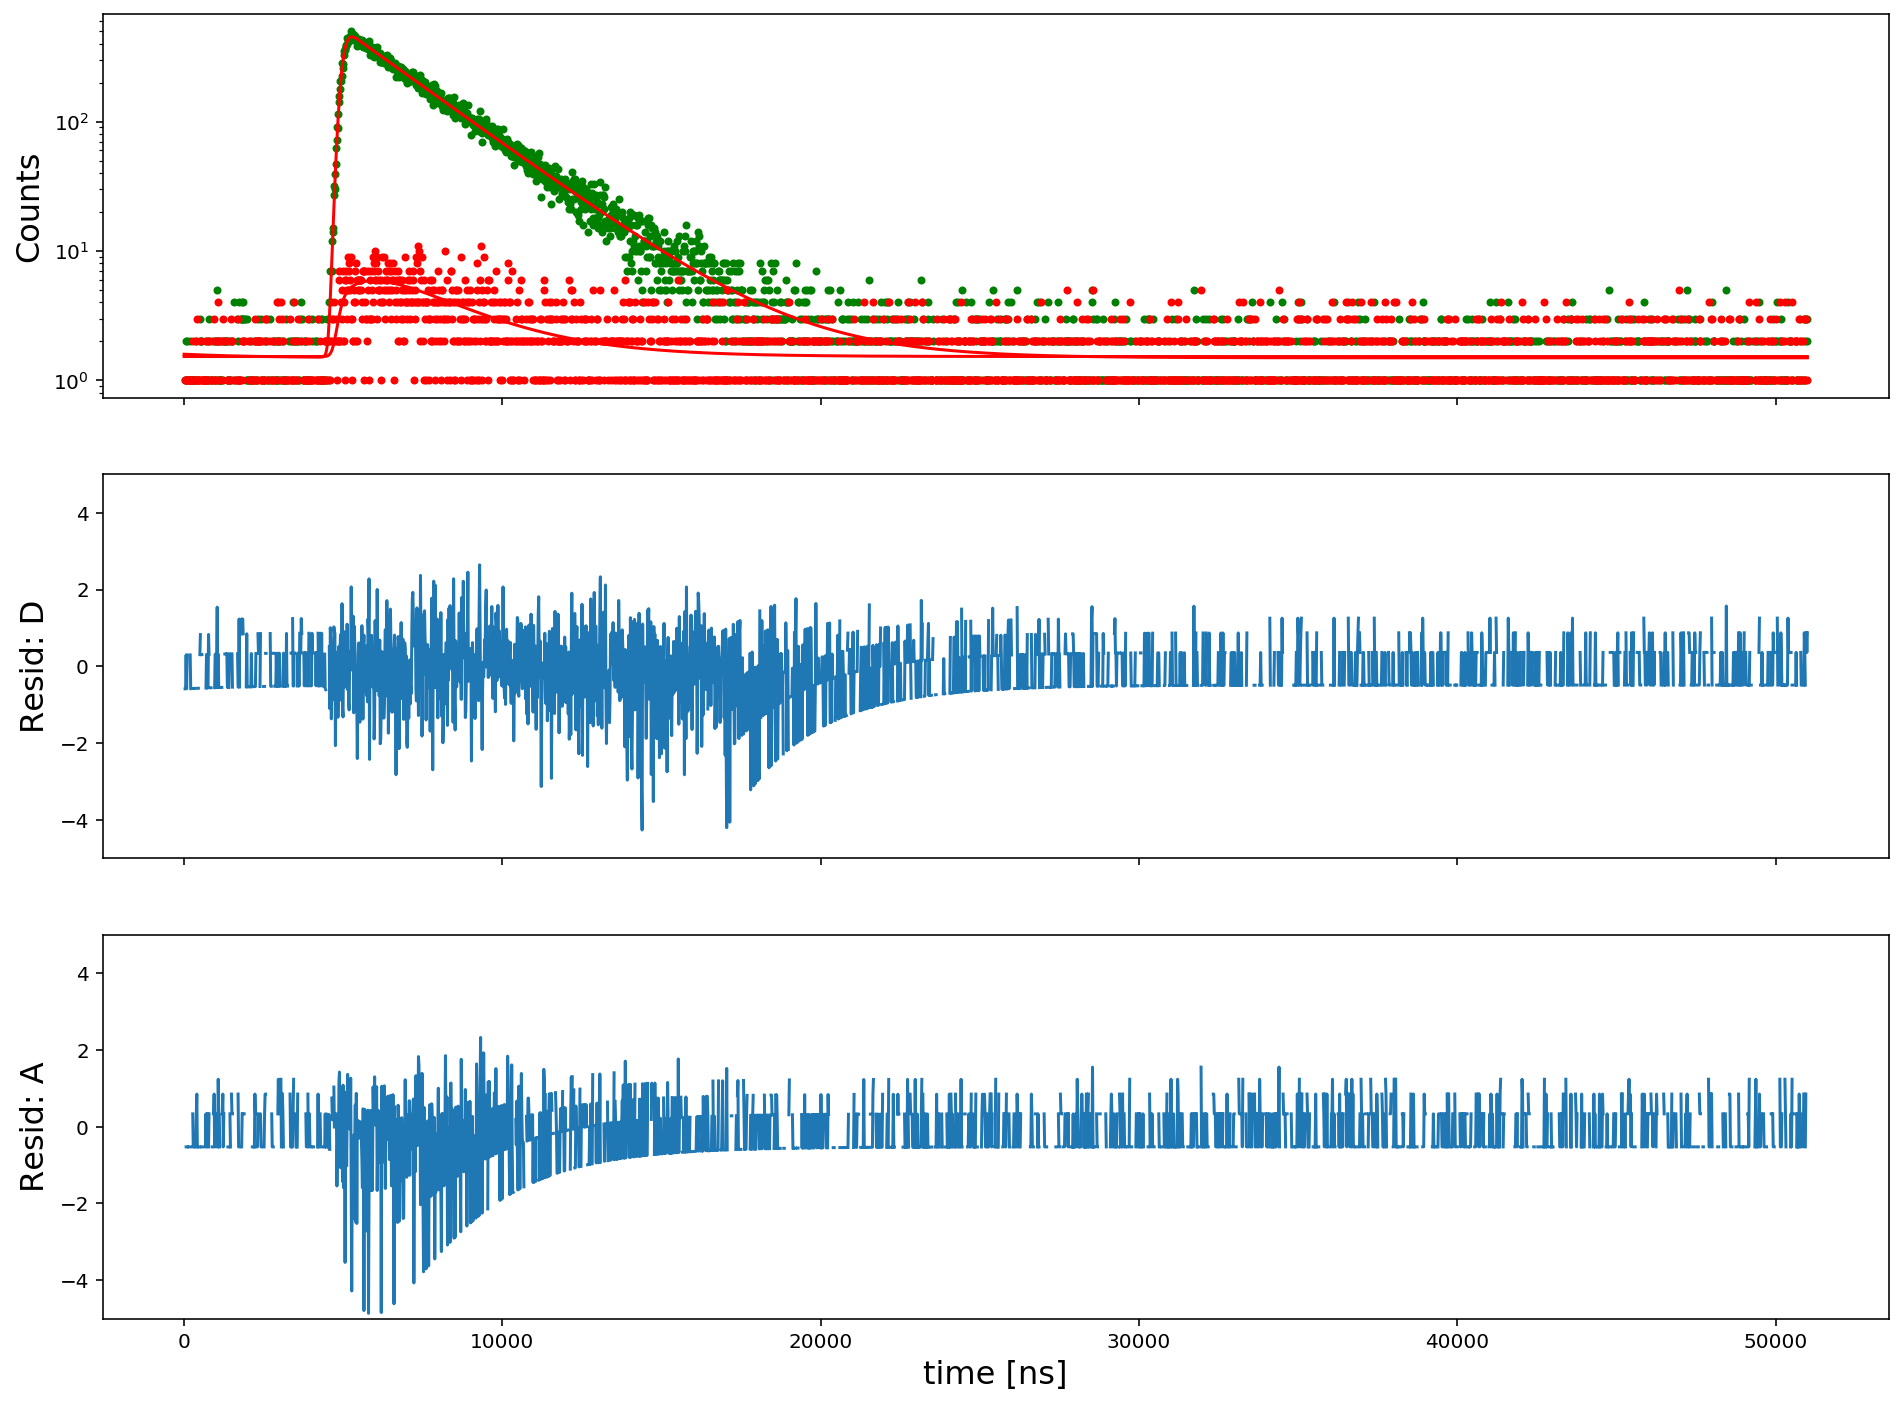

In [441]:
fig, ax = plt.subplots(3, 1, sharex = True)
ax[0].plot(t, sim_data[:, 1], 'g.', label = 'data')
ax[0].plot(t, sim_data[:, 3], 'r.')
ax[0].plot(t, fitted[:, 1], 'r-', label = 'fitted')
ax[0].plot(t, fitted[:, 3], 'r-')
ax[0].set(yscale = 'log', ylabel = 'Counts')
ax[2].set(xlabel = 'time [ns]')
ax[1].plot(t, (sim_data[:, 1] - fitted[:, 1])*1/np.sqrt(sim_data[:, 1]), '-')
ax[1].set(ylabel = 'Resid: D', ylim = (-5, 5))
ax[2].plot(t, (sim_data[:, 3] - fitted[:, 3])**1/np.sqrt(sim_data[:, 3]), '-')
ax[2].set(ylabel = 'Resid: A', ylim = (-5, 5))
plt.show()

## Fitting Donor-Acceptor Model to EGFP-mCherry Data

### PicoQuant TTTR Reading and Processing Functions

In [351]:
# Functions for reading and processing PicoQuant TTTR files
# Redefining ptu reading FLIM array building script as function
def readPTU(path):
    
    ptureadstream = open(path, 'rb')

    # Reading file magic to check if file is PTU file, first 8 byte
    filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

    # Checking file valiidy by reading file magic and file version
    if(filemagic != 'PQTTTR'):
        print('%s is not a .ptu file!' % path)
        ptureadstream.close()
    else:
        print('%s is a valid .ptu file... Commencing.' % path)

    
    fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
    print('File Version: %s' % fileversion)

    # Definition of header tag types
    '''
    Each header piece begins with a tag type. It is checked and depending on the type,
    different data types have to be extracted.
    '''

    tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
    tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
    tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
    tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
    tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
    tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
    tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
    tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
    tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
    tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
    tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

    # Defining record types
    '''
    Record types of different PicoQuant TCSPC devices. Different TCSPC devices,
    require different modes of photon record retrieval. See PicoQuant
    documentary for further information. 
    Here, only rtHydraHarp2T3 data are considered.
    '''
    rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
    rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
    rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
    rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
    rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
    rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
    rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
    rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
    rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
    rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
    rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
    rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]
    
    ## setting up header end string to terminate header decoding in while loop 
    headerend_tag = 'Header_End'
    reached_headerend = False


    # tuple that stores decoded information from header section
    header_contents = {}

    # decoding header
    while(reached_headerend == False):
        headerpiece = ptureadstream.read(48)
        tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
        tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
        tagType = struct.unpack('<i', headerpiece[36:40])[0]
        tagVal = headerpiece[40:48]

        if(tagId == headerend_tag):
            reached_headerend = True
            ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
            print('Found Header_End.')
            break

        if(tagType == tyEmpty8):
            header_contents['Empty'] =  'Empty'

        elif(tagType == tyBool8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyInt8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8):
            value = struct.unpack('<d', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8Array):
            value = struct.unpack("<q", tagVal)[0]
            print('Float array with %d entries' % value / 8)

        elif(tagType == tyAnsiString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('latin1').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyWideString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyBinaryBlob):
            value = struct.unpack("<q", tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyBitSet64):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyColor8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  "{0:#0{1}x}".format(value,18)

        elif(tagType == tyBinaryBlob):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyTDateTime):
            print(' ')

        else:
            continue
            #print('Unknown header tag type. Ignored.')
        
    
    headerend_bitoffset = ptureadstream.tell()
    
    FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'Comment': header_contents['$Comment'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
    }
    
        ## Data type definition for recordarray
    ### Data types are chosen, so that they use the least space possible
    recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                                  ('nanotime', np.float64), ('macrotime', np.float64)])


    # Preallocating array with decoded raw FLIM data
    recordarray = np.zeros(
            shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

    # Factors required to recover real macro and nanotimes from raw photon data stream
    macroMultFactor = FLIMInfo['GlobalResolution']
    nanoMultFactor = FLIMInfo['Resolution'] * 1e9


    # Opening .ptu file and shoveling it into UInt32 section of preallocated array
    with open(path, 'rb') as file:
        file.seek(headerend_bitoffset)
        recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
        file.close()

    # Recover marker signals and nanotimes of photon events
    recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
    recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor


    # Recover macrotimes and treat overflows
    recordarray = treatOverflows(recordarray, macroMultFactor)
    
    FLIMInfo['LinesInFile'] = countLines(recordarray)
    
    return(recordarray, FLIMInfo)


@jit(nopython=True)
def countLines(recordarray):
    '''
    Function: countLines(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    )
    
    - Counts number of line start (marker == 65) and line stop (marker == 66) events in raw photon data
    - Purpose: check data integrity
    '''

    numLinesStart = np.sum(recordarray['marker'] == 65)
    numLinesStop = np.sum(recordarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart


@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)

@jit(nopython=True, cache=True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in ns

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position
    # Count out-of-range photons (photons with macrotime below or above line time difference)
    oorPhotons = 0

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray['marker'][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray['macrotime'][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        while(lineActive == True):
            tmpMarker = recordarray['marker'][eventCounter]
            tmpMacro = recordarray['macrotime'][eventCounter]
            tmpNanotime = recordarray['nanotime'][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins) - 1

                    if(pixelIDY < 0 or pixelIDY > (nPixelY - 1)):
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1
        
    return flimarray, intensityImage

def calculate_overall_decay(data):
    decay = np.sum(np.sum(data[22:25, 22:25, :], axis = 0), axis = 0)
    return(decay)

def generate_time_axis(PTUdata, binFactor = 0):
    tEnd = PTUdata[1]['GlobalResolution'] * 1e12
    dt = PTUdata[1]['Resolution'] * 1e12
    numBins = math.ceil((tEnd/dt) / (2**binFactor))
    tAxis = np.linspace(0, tEnd, numBins)
    return(tAxis)

## EGFP-Only

../notebooks/data/20190418_EGFP.sptw/EGFP_only_2/EGFP_only_2_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00
 
Found Header_End.
(1607,) (1607,)


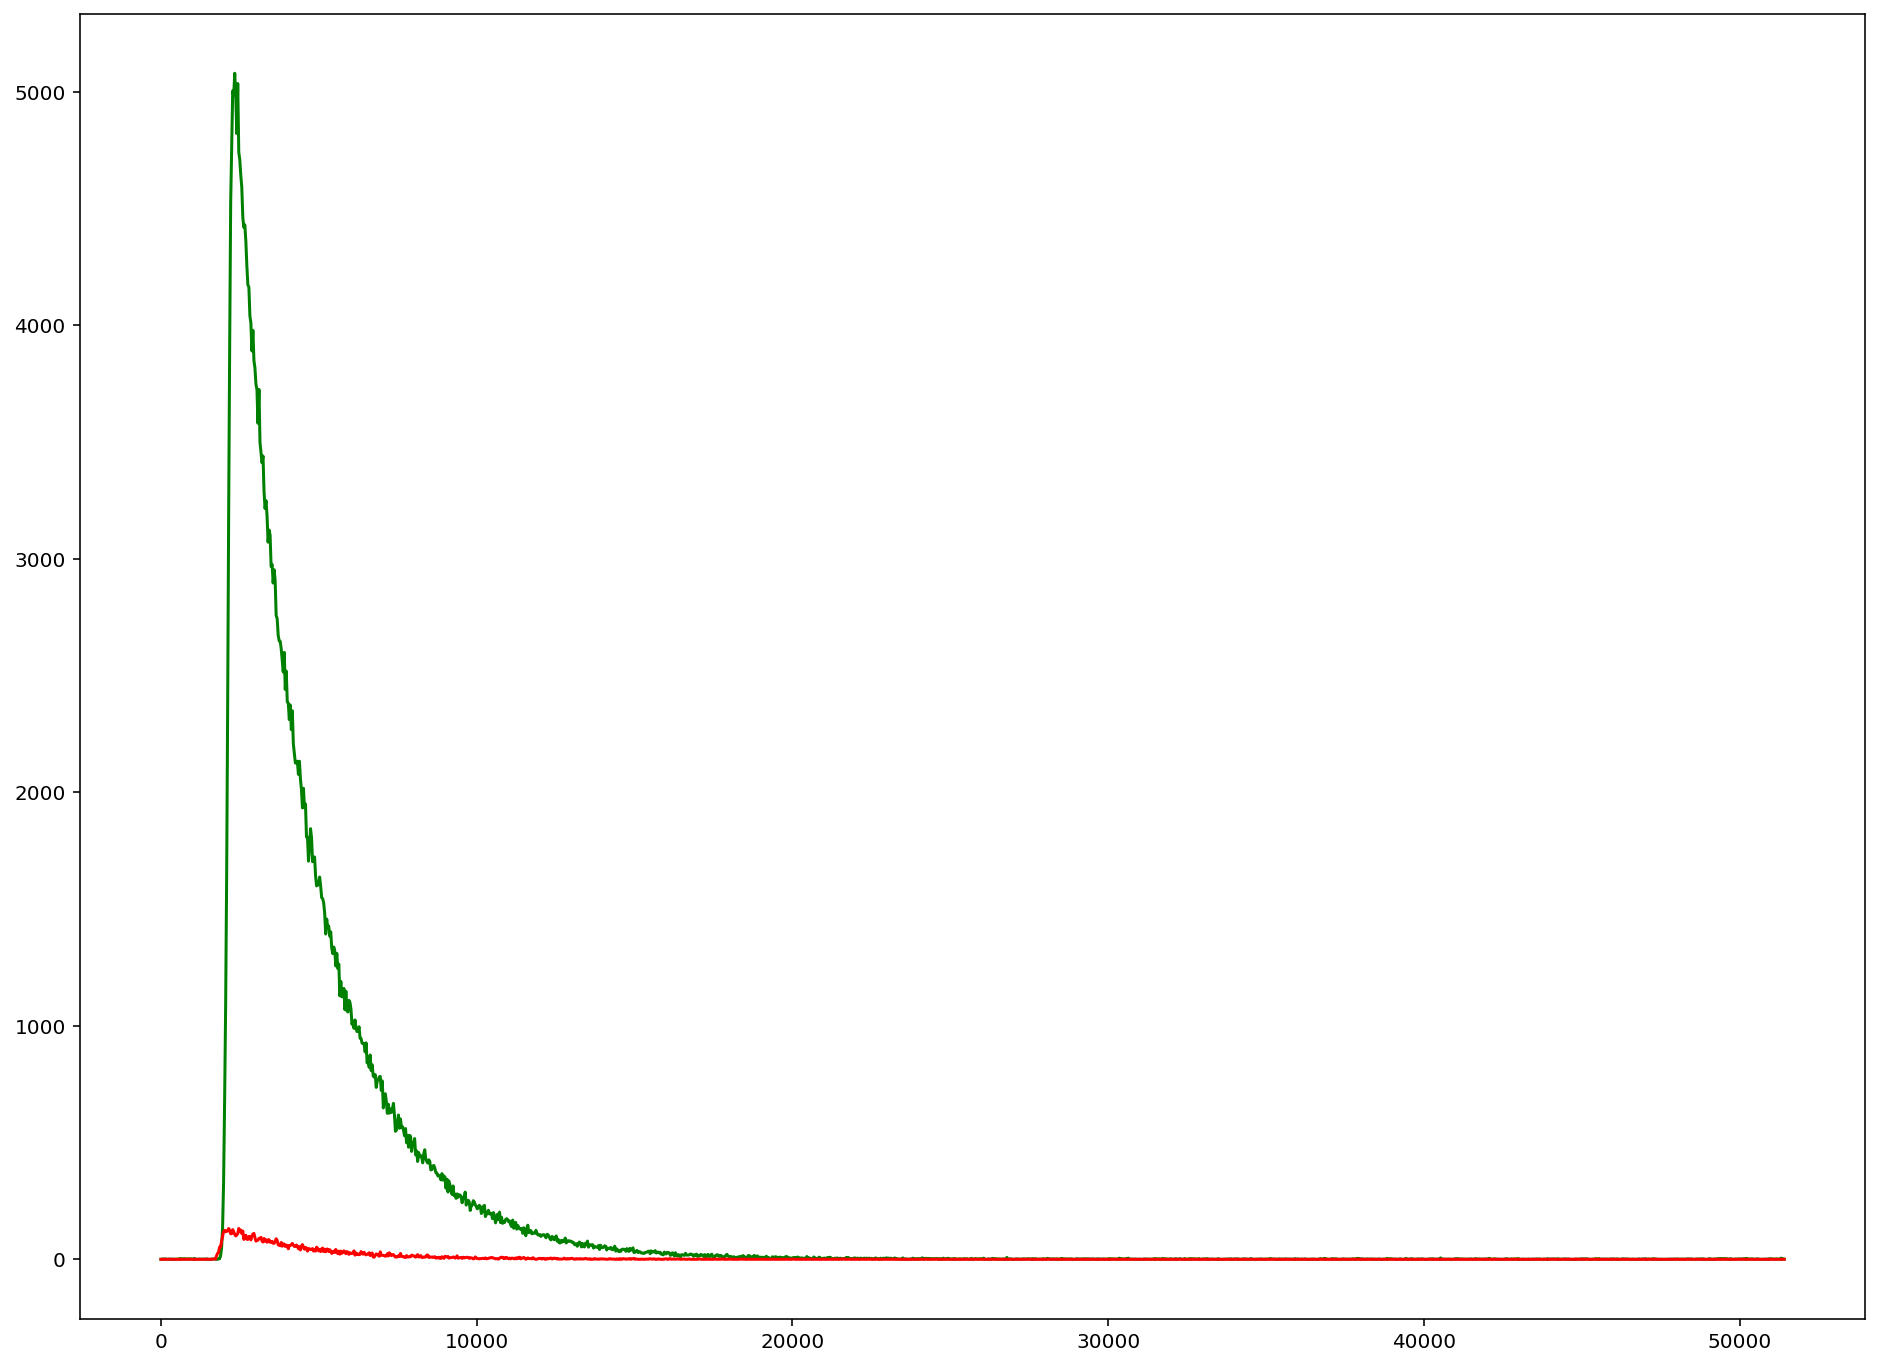

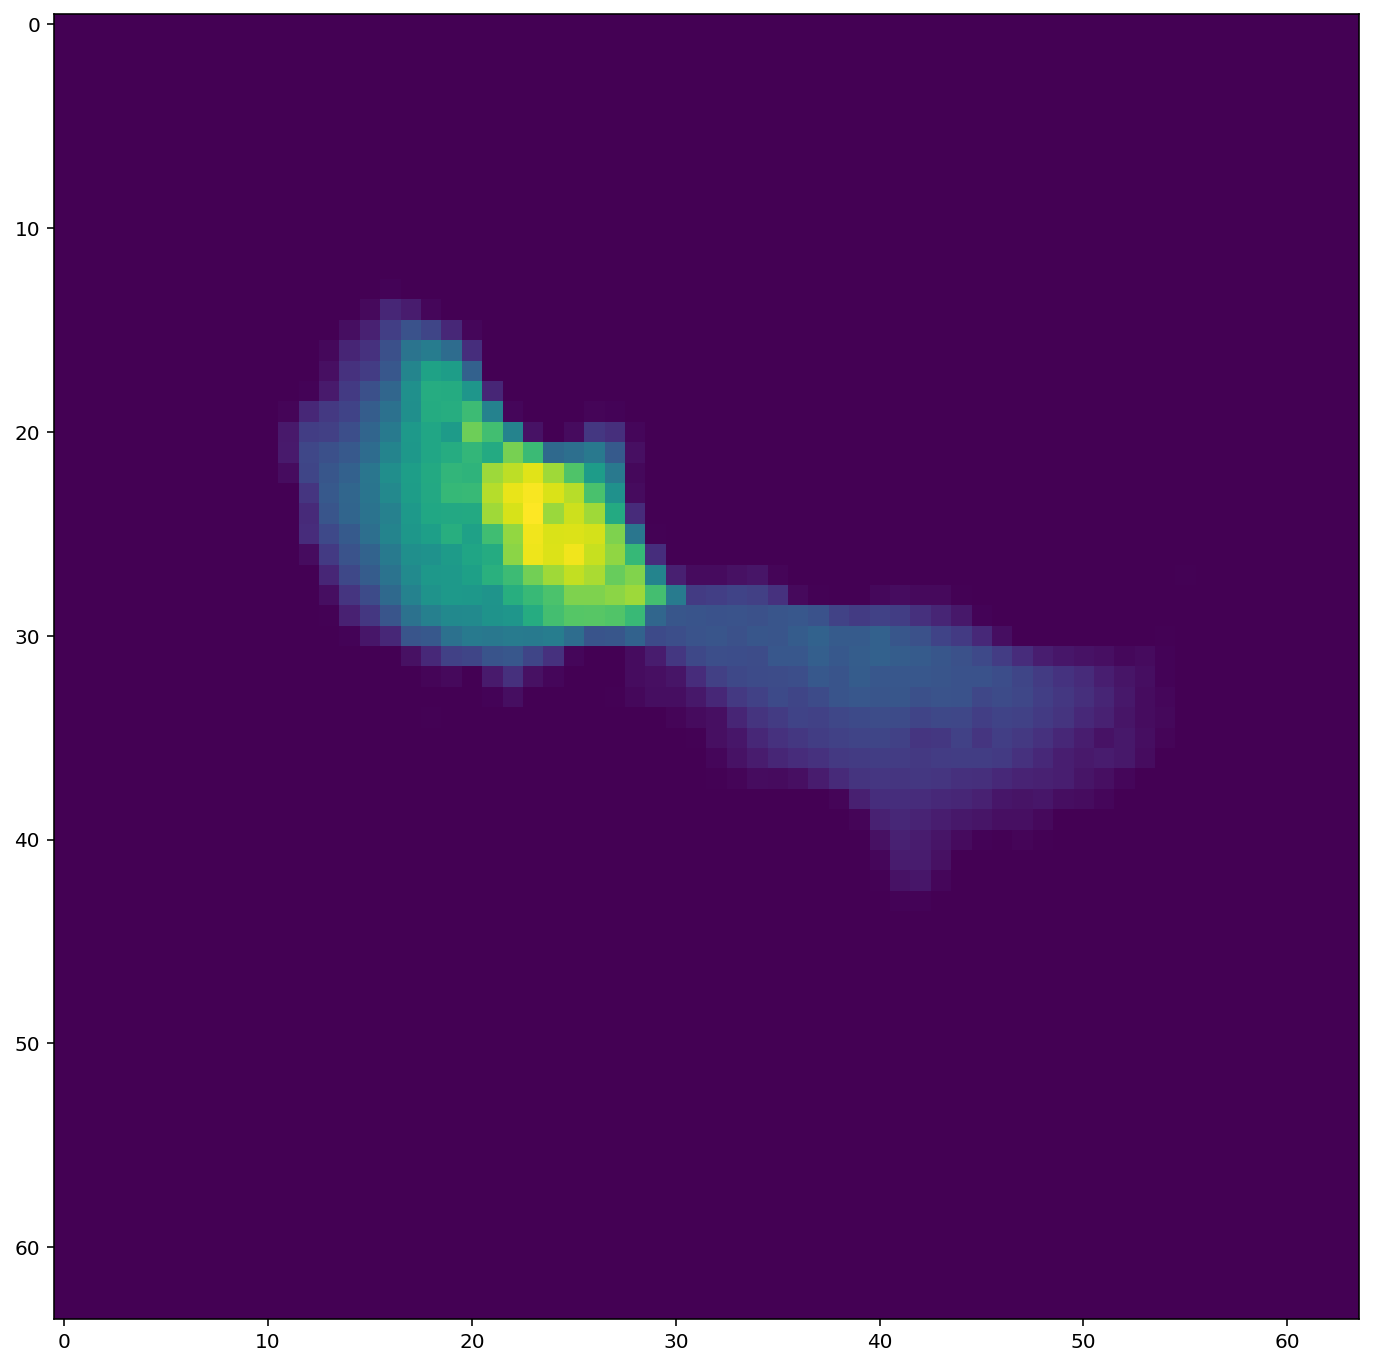

In [378]:
# Loading egfp decay for channel 1 and 2

spatialBin = 4
temporalBin = 1

egfp_raw = readPTU('../notebooks/data/20190418_EGFP.sptw/EGFP_only_2/EGFP_only_2_1.ptu')
egfp_c1, egfp_c1_intImg = buildFLIMArray(egfp_raw[0],
                                    channel = 0, 
                                    linesinfile = egfp_raw[1]['LinesInFile'],
                                    pixelsx = egfp_raw[1]['PixelsX'],
                                    pixelsy = egfp_raw[1]['PixelsY'],
                                    globRes = egfp_raw[1]['GlobalResolution'],
                                    timeRes = egfp_raw[1]['Resolution'],
                                    spatialBinning = spatialBin,
                                    temporalBinning = temporalBin)
egfp_c2, egfp_c2_intImg = buildFLIMArray(egfp_raw[0],
                                    channel = 1, 
                                    linesinfile = egfp_raw[1]['LinesInFile'],
                                    pixelsx = egfp_raw[1]['PixelsX'],
                                    pixelsy = egfp_raw[1]['PixelsY'],
                                    globRes = egfp_raw[1]['GlobalResolution'],
                                    timeRes = egfp_raw[1]['Resolution'],
                                    spatialBinning = spatialBin,
                                    temporalBinning = temporalBin)

tAxis = generate_time_axis(egfp_raw, binFactor = temporalBin)
egfp_c1_sumdecay = calculate_overall_decay(egfp_c1)
egfp_c2_sumdecay = calculate_overall_decay(egfp_c2)

print(tAxis.shape, egfp_c1_sumdecay.shape)

plt.plot(tAxis, egfp_c1_sumdecay, 'g-')
plt.plot(tAxis, egfp_c2_sumdecay, 'r-')
plt.yscale('linear')
plt.show()

plt.imshow(egfp_c1_intImg)
plt.show()

In [397]:
# Estmiating tau(EGFP) and btDA by fitting to EGFP-Only
decay = np.zeros((len(egfp_c1_sumdecay), 4))
decay[:, 1] = egfp_c1_sumdecay
decay[:, 3] = egfp_c2_sumdecay

mu_guessed = (np.where(decay[:, 1] == max(decay[:, 1]))[0][0]) * (tAxis[1] - tAxis[0]) 
as_guessed = (np.where(decay[:, 3] == max(decay[:, 3]))[0][0]) * (tAxis[1] - tAxis[0]) - mu_guessed

print(mu_guessed, as_guessed)

2337.013849704957 -192.08333011273635


In [412]:
para_start = (
    20000, # D(0) -> Number of ground state molecules at t = 0
    0, # D*(0)
    0, # A(0)
    0, # A*(0)
    2500, # kf_D -> Donor decay rate/
    200000, # k_r -> Rate of energy transfer
    2000, # kf_A -> Acceptor decay rate
    50, # sigma -> Width of excitation pulse
    mu_guessed, # mu -> t-offset of excitation pulse
    2, # offset_donor -> y-offset of donor decay
    2, # offset_acceptor -> y-offset of acceptor decay
    as_guessed, # acceptor_shift -> in ps
    80 # btDA -> spectral bleed-through of donor into acceptor channel
)

para_names = (
    "D(0)",
    "D*(0)",
    "A(0)",
    "A*(0)",
    "kf_D",
    "k_r",
    "kf_A",
    "sigma",
    "mu",
    "offD",
    "offA",
    "as",
    "btDA"
)

para_bounds = (
    (1, 100000), # D1
    (0, 0.1), # D0
    (1, 1000), # A1
    (0, 0.1), # A0
    (2000, 3000), # kf_D
    (95000, 200000), # k_r
    (1000, 2020), # kf_A
    (30, 200), # IRF sigma
    (1500, 2500), # IRF mu
    (0, 100), # offset_donor
    (0, 100), # offset_acceptor
    (-300, 300), # acceptor shift
    (1, 200) #  btDA
)
fit = optimize.minimize(
    residuals,
    para_start,
    args = (tAxis, decay),
    method = 'SLSQP',
    bounds = para_bounds,
    options = {
        #'ftol': 1e-5,
        'eps': 1,
        'disp': True
    }
)

/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:85: RuntimeWarning: divide by zero encountered in true_divide
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:85: RuntimeWarning: overflow encountered in true_divide
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:98: RuntimeWarning: invalid value encountered in true_divide
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:99: RuntimeWarning: invalid value encountered in true_divide
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:98: RuntimeWarning: divide by zero encountered in true_divide
/home/agbp/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:98: RuntimeWarning: overflow encountered in true_divide


Iteration limit exceeded    (Exit mode 9)
            Current function value: 7536.698236304332
            Iterations: 101
            Function evaluations: 2098
            Gradient evaluations: 101


(1607, 4) (1607, 4)


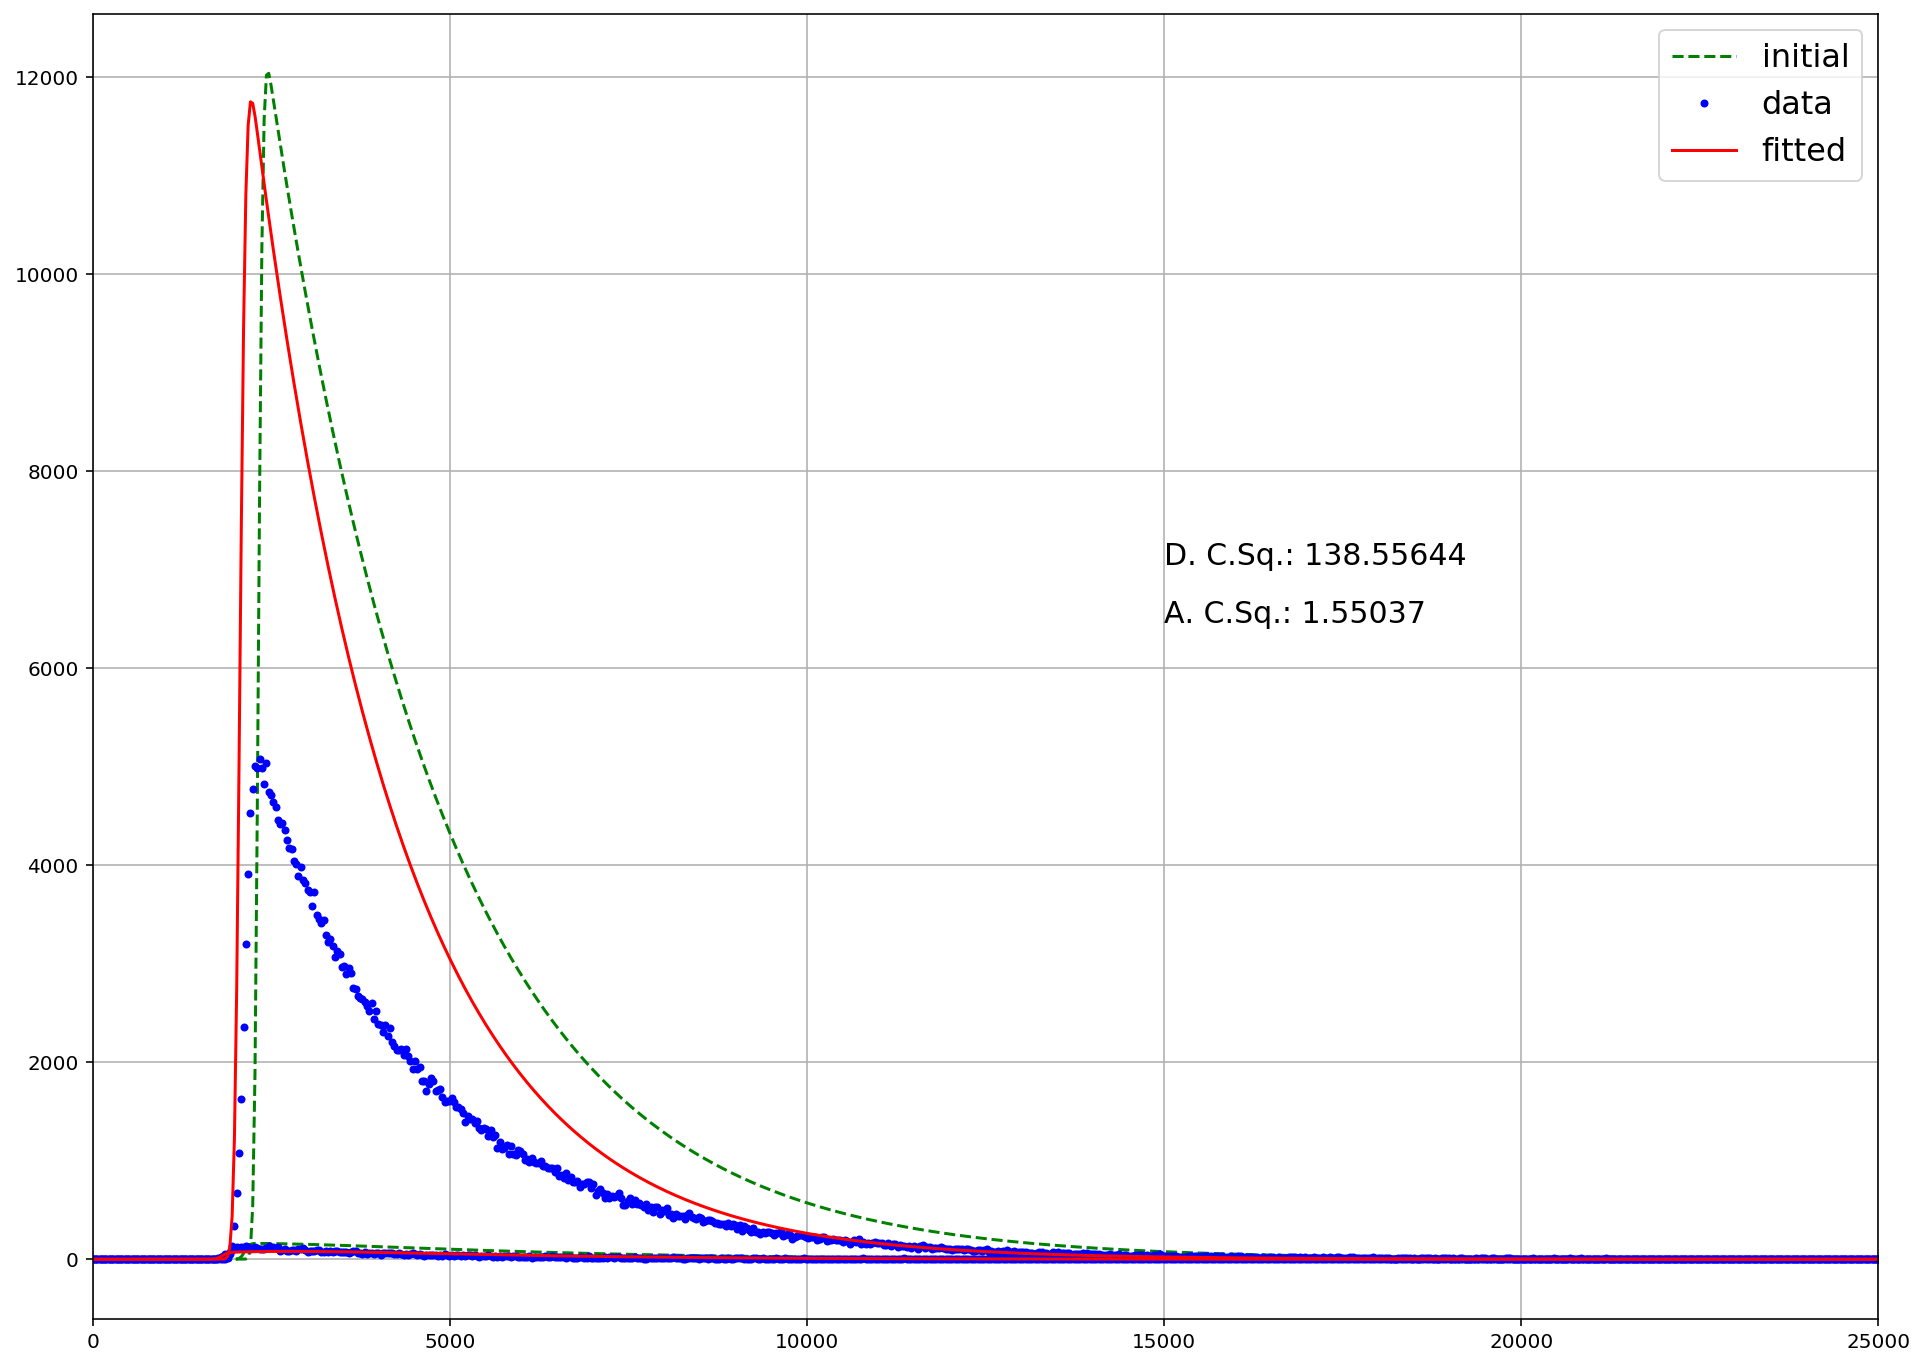

	Input Parameters	 Fitted Parameters
-----------------------------------------------------
D(0) 		 20000 		 19965.153237
D*(0) 		 0 		 0.018998
A(0) 		 0 		 1.048965
A*(0) 		 0 		 0.000392
kf_D 		 2500 		 2060.007819
k_r 		 200000 		 199999.999861
kf_A 		 2000 		 1934.74577
sigma 		 50 		 65.67772
mu 		 2337.01385 		 2084.783533
offD 		 2 		 1.054368
offA 		 2 		 0.063863
as 		 -192.08333 		 -280.539969
btDA 		 80 		 188.8923


In [413]:
initial_guess = eval_ode(tAxis, para_start, fitting = True)
fitted = eval_ode(tAxis, fit.x, fitting = True)

print(initial_guess.shape, fitted.shape)

# Getting red. chi-squared values for both curves
red_chi = calculate_chi_squred(
    data = decay,
    fit = fitted,
    number_fit_parameters = len(para_start)
)

plt.plot(tAxis, initial_guess[:, 1],  'g--', label = 'initial')
plt.plot(tAxis, initial_guess[:, 3],  'g--', )
plt.plot(tAxis, decay[:, 1],  'b.', label = 'data')
plt.plot(tAxis, decay[:, 3],  'b.')
plt.plot(tAxis, fitted[:, 1],  'r-', label = 'fitted')
plt.plot(tAxis, fitted[:, 3],  'r-')
plt.xlim(0, 25000)
plt.yscale('linear')
plt.legend(loc = 'best')
plt.grid()
plt.text(15000, 0.6 * np.max(fitted[:, 1]),
        s = 'D. C.Sq.: ' + str(round(red_chi[0], 5)),
        fontsize = 15 
)
plt.text(15000, 0.55 * np.max(fitted[:, 1]),
        s = 'A. C.Sq.: ' + str(round(red_chi[1], 5)),
        fontsize = 15 
)
plt.show()


print("\tInput Parameters\t Fitted Parameters")
print("-----------------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", round(para_start[i], 6), "\t\t", round(fit['x'][i], 6))

# Maximum Likelihood Estimatin for Donor-Acceptor FRET-FLIM Fitting
## Maximum Likelihood Estimation of Monoexponential, Reconvolutional Fitting


../notebooks/data/Fluoresceine_DilutionSereis_10nM_4/Fluoresceine_DilutionSereis_10nM_4_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00
 
Found Header_End.
../notebooks/data/191221_MicroscopeBenchmark_with_FPs.sptw/TCSPC_Benchmark_EGFP_wNF488_1/TCSPC_Benchmark_EGFP_wNF488_1_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00
 
Found Header_End.
(2800,) (2800,)


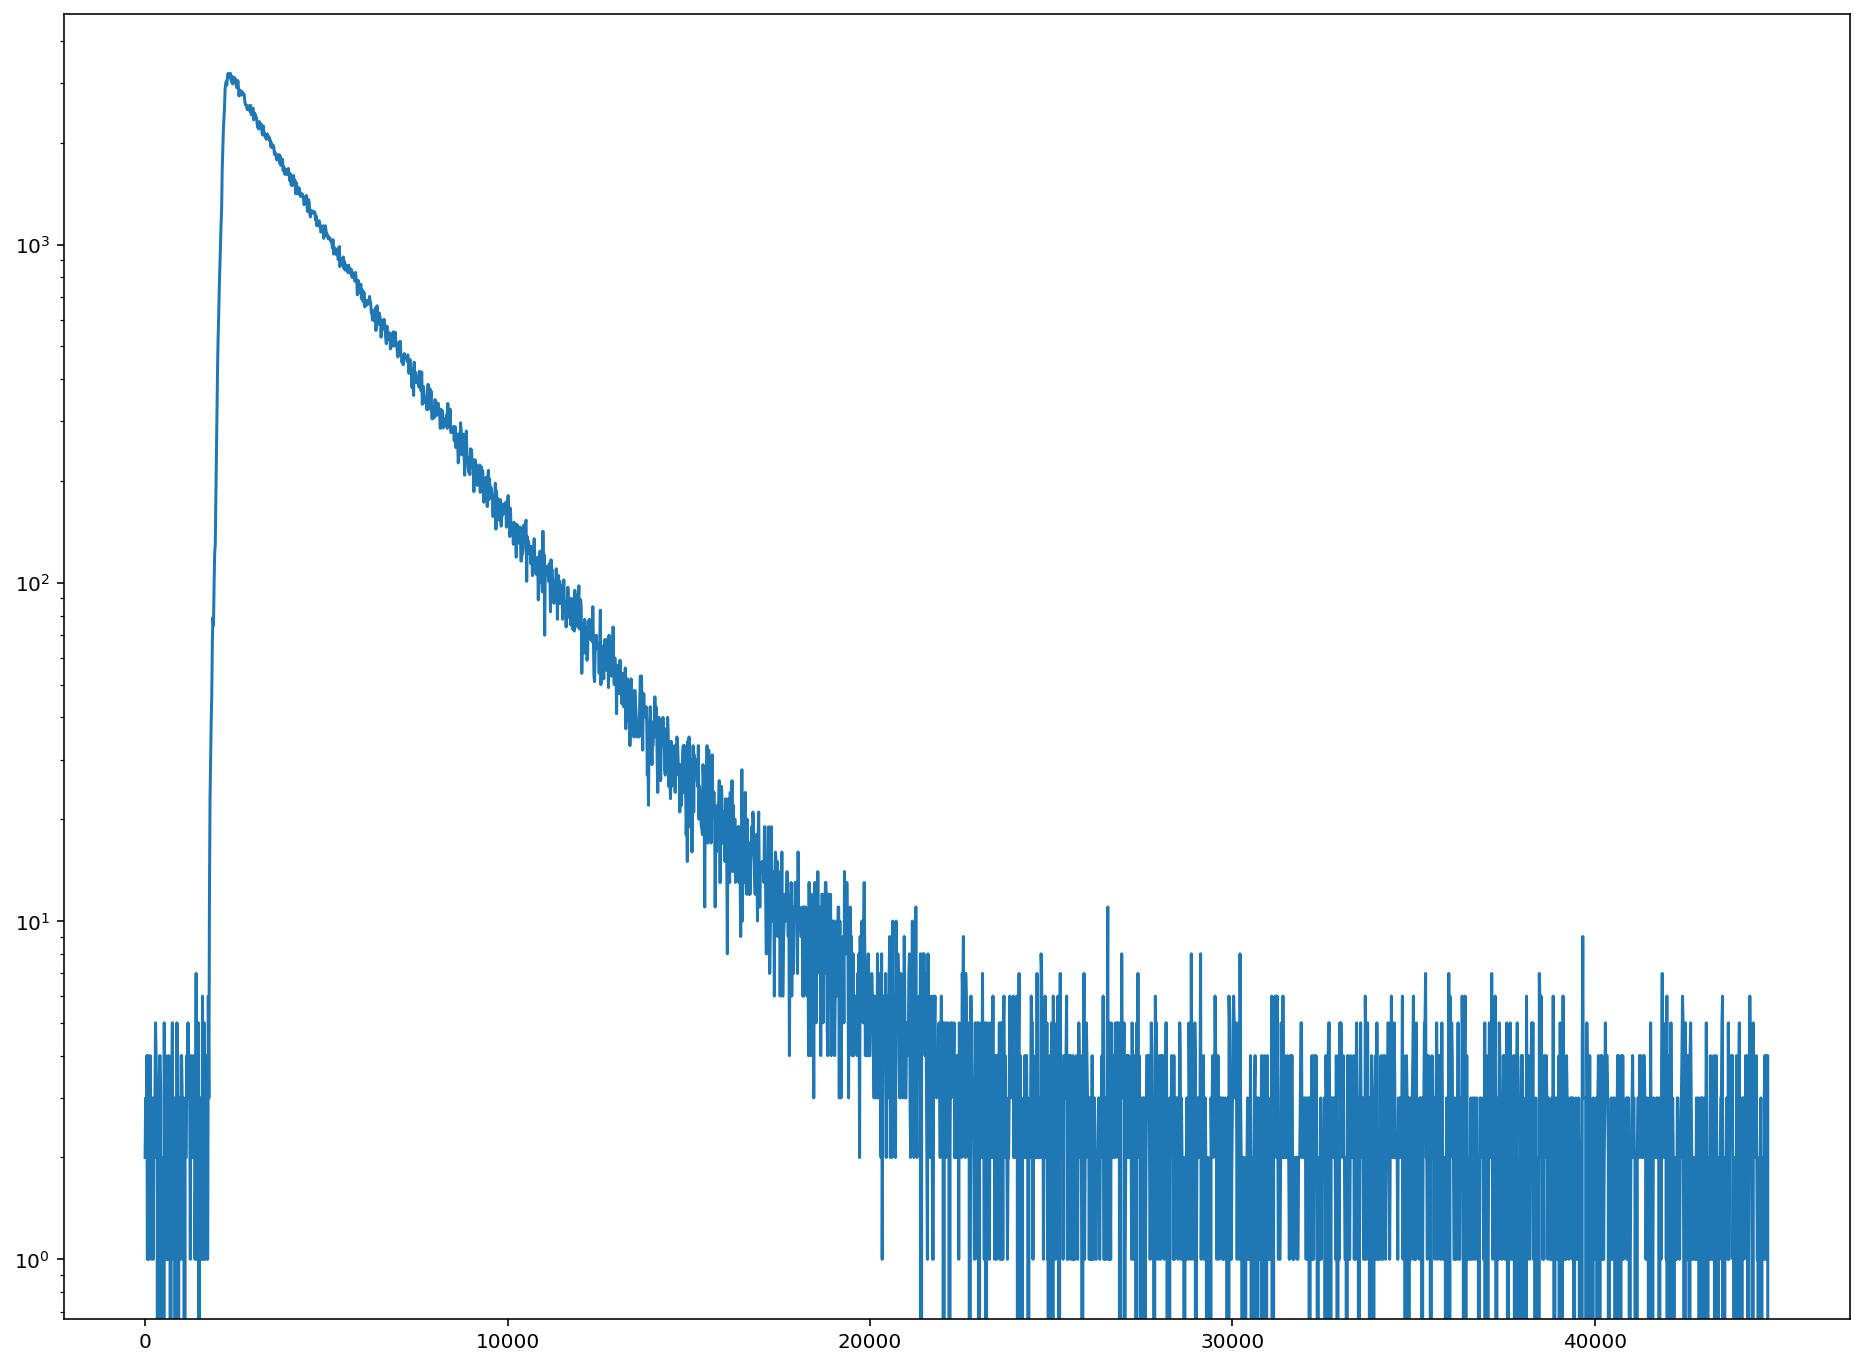

In [26]:
# Importing required modules and setting up matplotlib
import struct, io, os, math
from scipy.integrate import odeint
import scipy.optimize as optimize
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from scipy.optimize import curve_fit
import scipy.stats as stats
from scipy.integrate import odeint
from numba import jit


%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

# Redefining ptu reading FLIM array building script as function
def readPTU(path):
    
    ptureadstream = open(path, 'rb')

    # Reading file magic to check if file is PTU file, first 8 byte
    filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

    # Checking file valiidy by reading file magic and file version
    if(filemagic != 'PQTTTR'):
        print('%s is not a .ptu file!' % path)
        ptureadstream.close()
    else:
        print('%s is a valid .ptu file... Commencing.' % path)

    
    fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
    print('File Version: %s' % fileversion)

    # Definition of header tag types
    '''
    Each header piece begins with a tag type. It is checked and depending on the type,
    different data types have to be extracted.
    '''

    tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
    tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
    tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
    tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
    tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
    tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
    tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
    tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
    tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
    tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
    tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

    # Defining record types
    '''
    Record types of different PicoQuant TCSPC devices. Different TCSPC devices,
    require different modes of photon record retrieval. See PicoQuant
    documentary for further information. 
    Here, only rtHydraHarp2T3 data are considered.
    '''
    rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
    rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
    rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
    rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
    rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
    rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
    rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
    rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
    rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
    rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
    rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
    rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]
    
    ## setting up header end string to terminate header decoding in while loop 
    headerend_tag = 'Header_End'
    reached_headerend = False


    # tuple that stores decoded information from header section
    header_contents = {}

    # decoding header
    while(reached_headerend == False):
        headerpiece = ptureadstream.read(48)
        tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
        tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
        tagType = struct.unpack('<i', headerpiece[36:40])[0]
        tagVal = headerpiece[40:48]

        if(tagId == headerend_tag):
            reached_headerend = True
            ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
            print('Found Header_End.')
            break

        if(tagType == tyEmpty8):
            header_contents['Empty'] =  'Empty'

        elif(tagType == tyBool8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyInt8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8):
            value = struct.unpack('<d', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8Array):
            value = struct.unpack("<q", tagVal)[0]
            print('Float array with %d entries' % value / 8)

        elif(tagType == tyAnsiString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('latin1').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyWideString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyBinaryBlob):
            value = struct.unpack("<q", tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyBitSet64):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyColor8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  "{0:#0{1}x}".format(value,18)

        elif(tagType == tyBinaryBlob):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyTDateTime):
            print(' ')

        else:
            continue
            #print('Unknown header tag type. Ignored.')
        
    
    headerend_bitoffset = ptureadstream.tell()
    
    FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'Comment': header_contents['$Comment'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
    }
    
        ## Data type definition for recordarray
    ### Data types are chosen, so that they use the least space possible
    recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                                  ('nanotime', np.float64), ('macrotime', np.float64)])


    # Preallocating array with decoded raw FLIM data
    recordarray = np.zeros(
            shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

    # Factors required to recover real macro and nanotimes from raw photon data stream
    macroMultFactor = FLIMInfo['GlobalResolution']
    nanoMultFactor = FLIMInfo['Resolution'] * 1e9


    # Opening .ptu file and shoveling it into UInt32 section of preallocated array
    with open(path, 'rb') as file:
        file.seek(headerend_bitoffset)
        recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
        file.close()

    # Recover marker signals and nanotimes of photon events
    recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
    recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor


    # Recover macrotimes and treat overflows
    recordarray = treatOverflows(recordarray, macroMultFactor)
    
    FLIMInfo['LinesInFile'] = countLines(recordarray)
    
    return(recordarray, FLIMInfo)


@jit(nopython=True)
def countLines(recordarray):
    '''
    Function: countLines(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    )
    
    - Counts number of line start (marker == 65) and line stop (marker == 66) events in raw photon data
    - Purpose: check data integrity
    '''

    numLinesStart = np.sum(recordarray['marker'] == 65)
    numLinesStop = np.sum(recordarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart


@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)

@jit(nopython=True, cache=True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in ns

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position
    # Count out-of-range photons (photons with macrotime below or above line time difference)
    oorPhotons = 0

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray['marker'][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray['macrotime'][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        while(lineActive == True):
            tmpMarker = recordarray['marker'][eventCounter]
            tmpMacro = recordarray['macrotime'][eventCounter]
            tmpNanotime = recordarray['nanotime'][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins) - 1

                    if(pixelIDY < 0 or pixelIDY > (nPixelY - 1)):
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1
        
    return flimarray, intensityImage

# Fitting using reconvolution method - mono exponential

def gauss_laser(t, mu, sigma):
    y = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(t - mu)**2/(2*sigma)**2)
    return(y)

def expDecay(t, N0, tau1):
    return(N0 * np.exp(-t/tau1))

def convolutedDecay(t, offset, amp1, tau1, IRFmu, IRFsigma, scatter, fitting = False):
    IRF = gauss_laser(t, IRFmu, IRFsigma)
    IRFscatter = IRF * scatter
    decay = expDecay(t, amp1, tau1)
    
    convolvedSignal = np.convolve(IRF, decay, mode = 'full')[0:len(t)]
    convolvedSignal += IRFscatter
    
    if(fitting == False): # Set fitting to True to suppress addition of Poisson noise, set True when simulating a decay
        convolvedSignal = addPoissonNoise(convolvedSignal, offset)
    else:
        convolvedSignal += offset
    
    return(convolvedSignal)

def addPoissonNoise(decay, offset):
    decay = np.random.poisson(decay, len(decay))
    decay += np.random.poisson(offset, len(decay))
    
    return(decay)
    

def estimateBackground(data):
    '''
        Calculates median of last 7 % of data.
        Used for weighting of 0 values; would otherwise lead to division by 0. Instead,
        the weight for the median background value is used for residue weighting.
    '''
    sampleIndex_rightcutoff = math.floor(len(data)*0.97)
    sampleIndex_leftcutoff = math.floor(len(data)*0.90)

    background = np.median(data[sampleIndex_leftcutoff:sampleIndex_rightcutoff])
    
    return(background)

def calculateWeights(data):
    weights = np.zeros((len(data)))
    weights = 1./np.sqrt(data, where = (data != 0))
    weights[np.where(data == 0)] = 1./np.sqrt(estimateBackground(data))
    return(weights)
    

# Objective function
def residuals(para_est, t, data, weighted = True):
    if(weighted == True):
        weights = calculateWeights(data)
        resids = (data - convolutedDecay(t, *para_est, True))**2 * weights
    else:
        resids = (data - convolutedDecay(t, *para_est, True))**2
        
    return(resids)

# Minimization approaches
## Least-Squares Minimization
def minimization_least_squares(para_est, t, data, weighted = False):
    
    fitted = convolutedDecay(t, *para_est, fitting = True)
    
    if(weighted == True):
        weights = calculateWeights(data)
        resids = ((data - fitted)**2 * weights) / fitted
    else:
        resids = ((data - fitted)**2) / fitted
    
    resids = np.nansum(resids)
    
    return(resids)


# Loading fluoresceine decay
fluoresceine_raw = readPTU('../notebooks/data/Fluoresceine_DilutionSereis_10nM_4/Fluoresceine_DilutionSereis_10nM_4_1.ptu')
fluoresceine_raw = readPTU('../notebooks/data/191221_MicroscopeBenchmark_with_FPs.sptw/TCSPC_Benchmark_EGFP_wNF488_1/TCSPC_Benchmark_EGFP_wNF488_1_1.ptu')
fluoresceine_c1, fluoresceine_c1_intImg = buildFLIMArray(fluoresceine_raw[0],
                                    channel = 0, 
                                    linesinfile = fluoresceine_raw[1]['LinesInFile'],
                                    pixelsx = fluoresceine_raw[1]['PixelsX'],
                                    pixelsy = fluoresceine_raw[1]['PixelsY'],
                                    globRes = fluoresceine_raw[1]['GlobalResolution'],
                                    timeRes = fluoresceine_raw[1]['Resolution'],
                                    spatialBinning = 5,
                                    temporalBinning = 0)
fluoresceine_c1_sumDecay = np.sum(np.sum(fluoresceine_c1, axis=0), axis=0)[0:2800]

# Generating time axis from TCSPC data
tEnd = fluoresceine_raw[1]['GlobalResolution'] * 1e12
dt = fluoresceine_raw[1]['Resolution'] * 1e12
numBins = math.ceil((tEnd/dt))
tAxis = np.linspace(0, tEnd, numBins)[0:2800]
print(tAxis.shape, fluoresceine_c1_sumDecay.shape)

plt.plot(tAxis, fluoresceine_c1_sumDecay)
plt.yscale('log')
plt.show()

`ftol` termination condition is satisfied.
Function evaluations 95, initial cost 2.8163e+15, final cost 3.1312e+09, first-order optimality 1.39e+05.


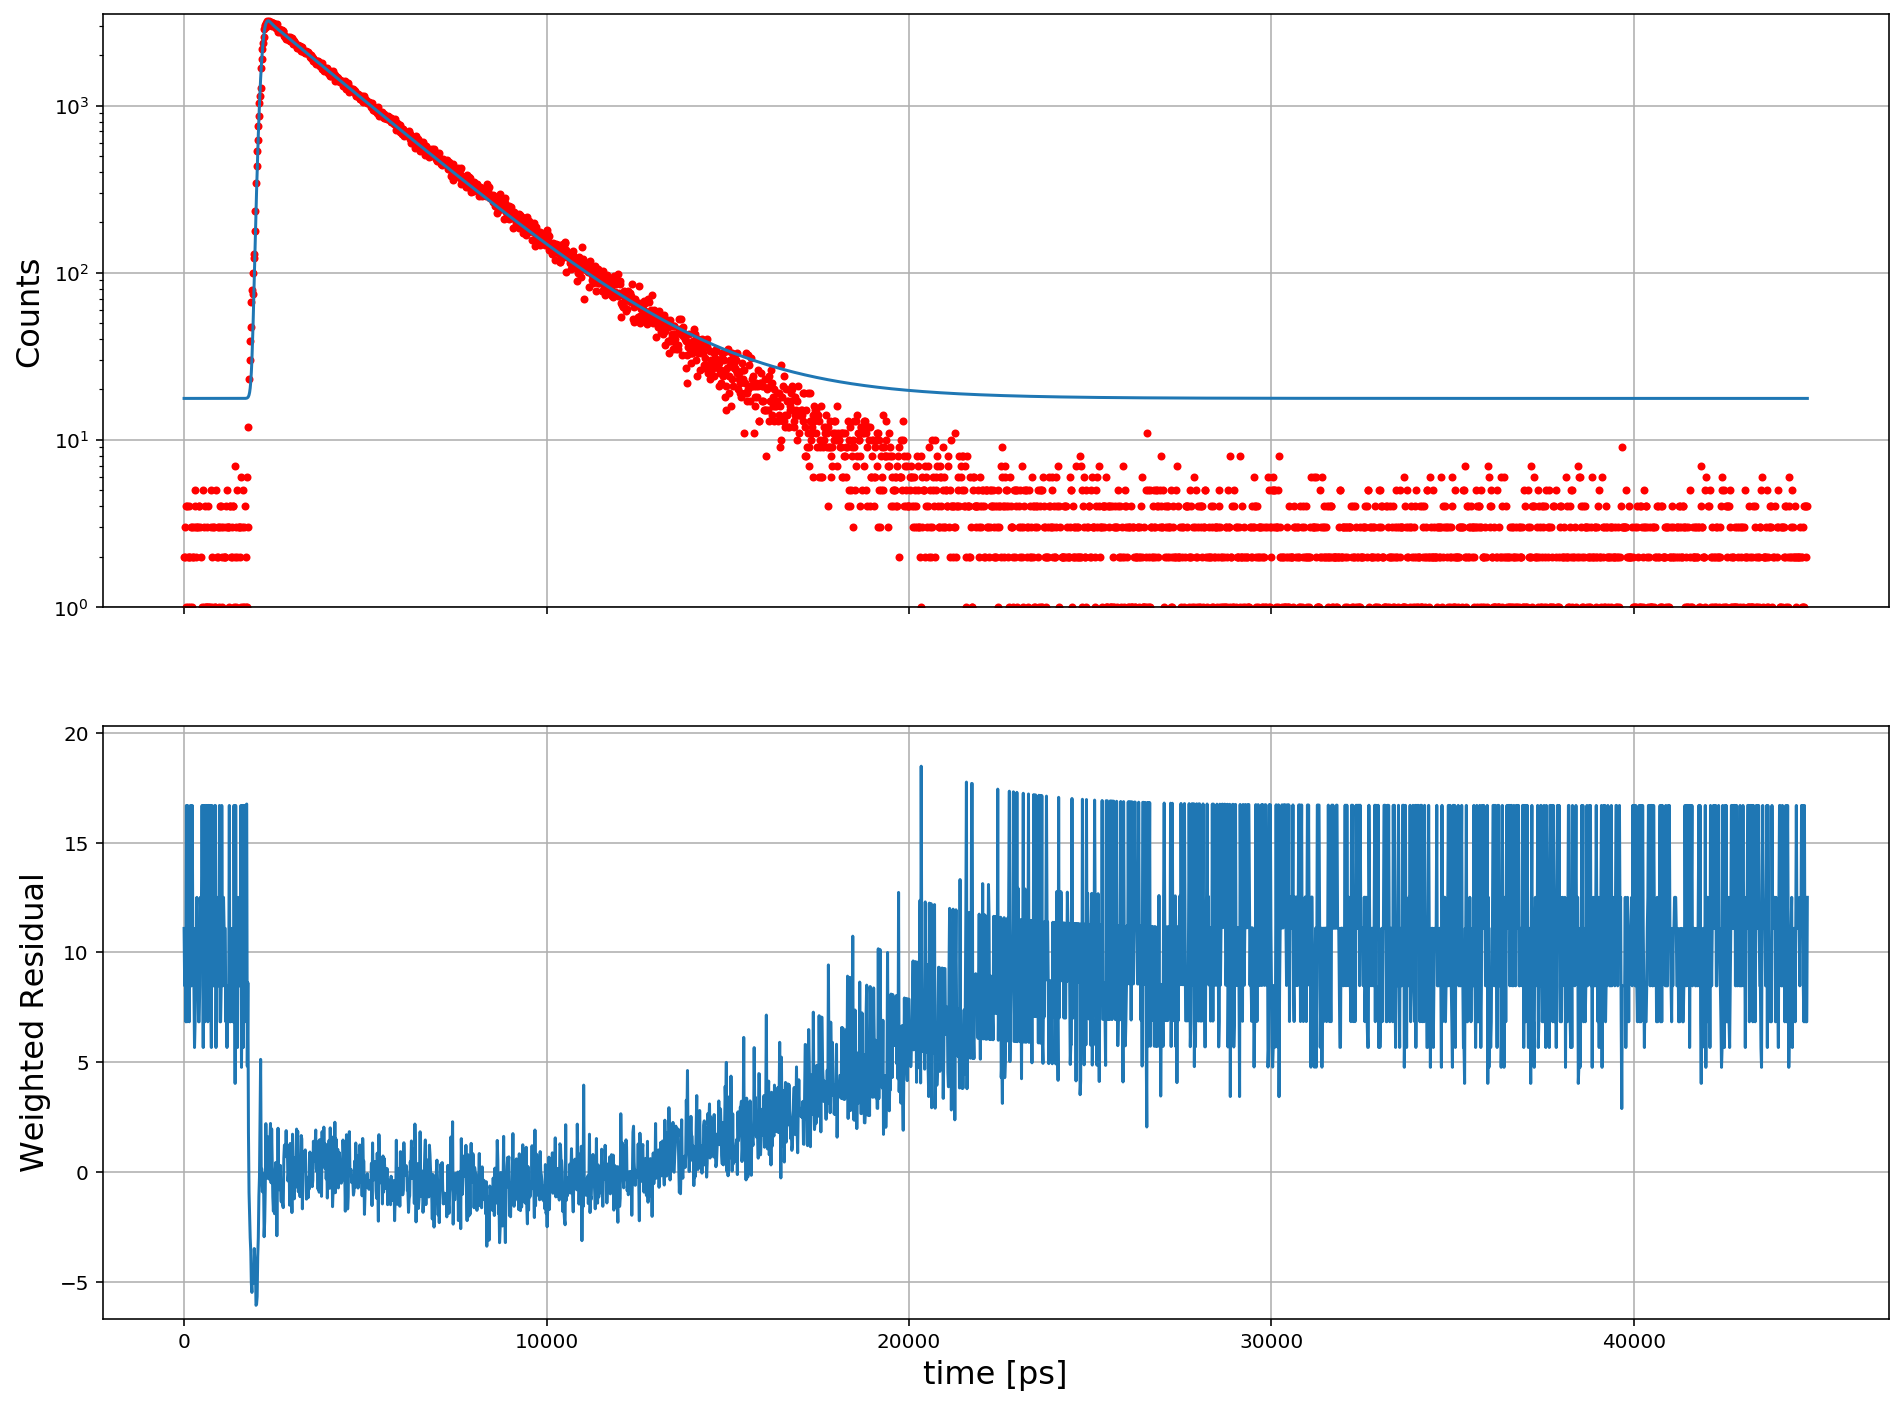

	Input Parameters	 Fitted Parameters
---------------------------------------------
offset 		 2.0 			 17.690005304581575
amp1 		 50000 			 37976.4345183626
tau1 		 2500 			 2408.03506609573
mu 		 1500 			 2184.3624640776484
sig 		 100 			 73.01929629571352
Scat 		 32080.0 			 130463.85503375775


Chi-Sq (abs. / red.):	 25448.634477119325 	 9.10831584721522
Chi-Sq (SciPy):		 25448.634477119325 	 9.10831584721522  (p-value: 0.0 )



In [27]:
# Fitting by optimizing towards residuals
## Defining fitting function and perfoming fit
## Initial guessing and Data Fitting
para_start = (
    estimateBackground(fluoresceine_c1_sumDecay), # offset
    50000, # Amplitude 1
    2500, # tau 1
    1500, # Laser mu / shift
    100, # Laser sigma
    max(fluoresceine_c1_sumDecay)*10 # Scatter
)

para_names = (
    "offset",
    "amp1",
    "tau1",
    "mu",
    "sig",
    "Scat"
)


para_bounds = (
    (0, # offset
     1, # amp1
     200, # tau1
     10, # IRFmu
     20, # IRFsigma
     0), # Scatter
    (1000,
     500000,
     10000,
     10000,
     500,
     np.infty)
)
    
para_opt = optimize.least_squares(residuals,
                                  para_start,
                                  method = 'trf',
                                  ftol = 1e-15,
                                  xtol = 1e-15,
                                  args = (tAxis, fluoresceine_c1_sumDecay, False),
                                  bounds = para_bounds,
                                  max_nfev = 10000,
                                  verbose = 1)


fitted_curve = convolutedDecay(tAxis, *para_opt['x'], True)
weighted_resid = (fitted_curve - fluoresceine_c1_sumDecay)*calculateWeights(fluoresceine_c1_sumDecay)

fig, ax = plt.subplots(2, 1, sharex = True)
fig.suptitle = 'test'
ax[0].plot(tAxis, fluoresceine_c1_sumDecay, 'r.')
ax[0].plot(tAxis, fitted_curve)
ax[0].set(ylim = (1, max(fluoresceine_c1_sumDecay)*1.1), ylabel = 'Counts', yscale = 'log')
ax[0].grid()
ax[1].plot(tAxis, weighted_resid)
ax[1].set(xlabel = 'time [ps]', ylabel = 'Weighted Residual', ylim = (min(weighted_resid)*1.1, max(weighted_resid)*1.1))
ax[1].grid()
plt.savefig('../notebooks/monoFit.pdf', format = 'pdf')
plt.show()

print("\tInput Parameters\t Fitted Parameters")
print("---------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", para_start[i], "\t\t\t", para_opt['x'][i])


# Chi-Squared
chisq = np.sum(((fluoresceine_c1_sumDecay - fitted_curve)**2)/fitted_curve)
chisq_scipy = stats.chisquare(fluoresceine_c1_sumDecay, fitted_curve, len(para_start))

chisq_red = chisq/(len(fluoresceine_c1_sumDecay) - len(para_start))
df = len(fluoresceine_c1_sumDecay) - len(para_start)

print("\n")
print("Chi-Sq (abs. / red.):\t", chisq, "\t", chisq_red)
print("Chi-Sq (SciPy):\t\t", chisq_scipy[0], "\t", chisq_scipy[0]/df, " (p-value:", chisq_scipy[1], ")\n")

#### Minizining Least Squares (Standard Least Squares Approach)

$$\text{minimize} \quad \chi^2 = \sum_{i = 1}^{n} \Bigg[ \frac{\big(d_i(t) - f_i(t; \theta)\big)}{d_i(t)} \Bigg]$$

with $d(t)$ as the measured fluorescence decay and $f(t; \theta)$ as the fitted function given the set of parameters $\theta$.

/home/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:409: RuntimeWarning: divide by zero encountered in true_divide
/home/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:409: RuntimeWarning: overflow encountered in true_divide


	Input Parameters	 Fitted Parameters
---------------------------------------------
offset 		 10 			 2.4358711245574916
amp1 		 50000 			 36936.75274241442
tau1 		 2500 			 2587.1845019717243
mu 		 3000 			 2145.356134782676
sig 		 100 			 85.913771821279
Scat 		 32080.0 			 31991.656321664937


Chi-Sq (abs. / red.):	 3933.6487097967115 	 1.4078914494619583
Chi-Sq (SciPy):		 3933.6487097967115 	 1.4078914494619583  (p-value: 2.6298243926569098e-42 )



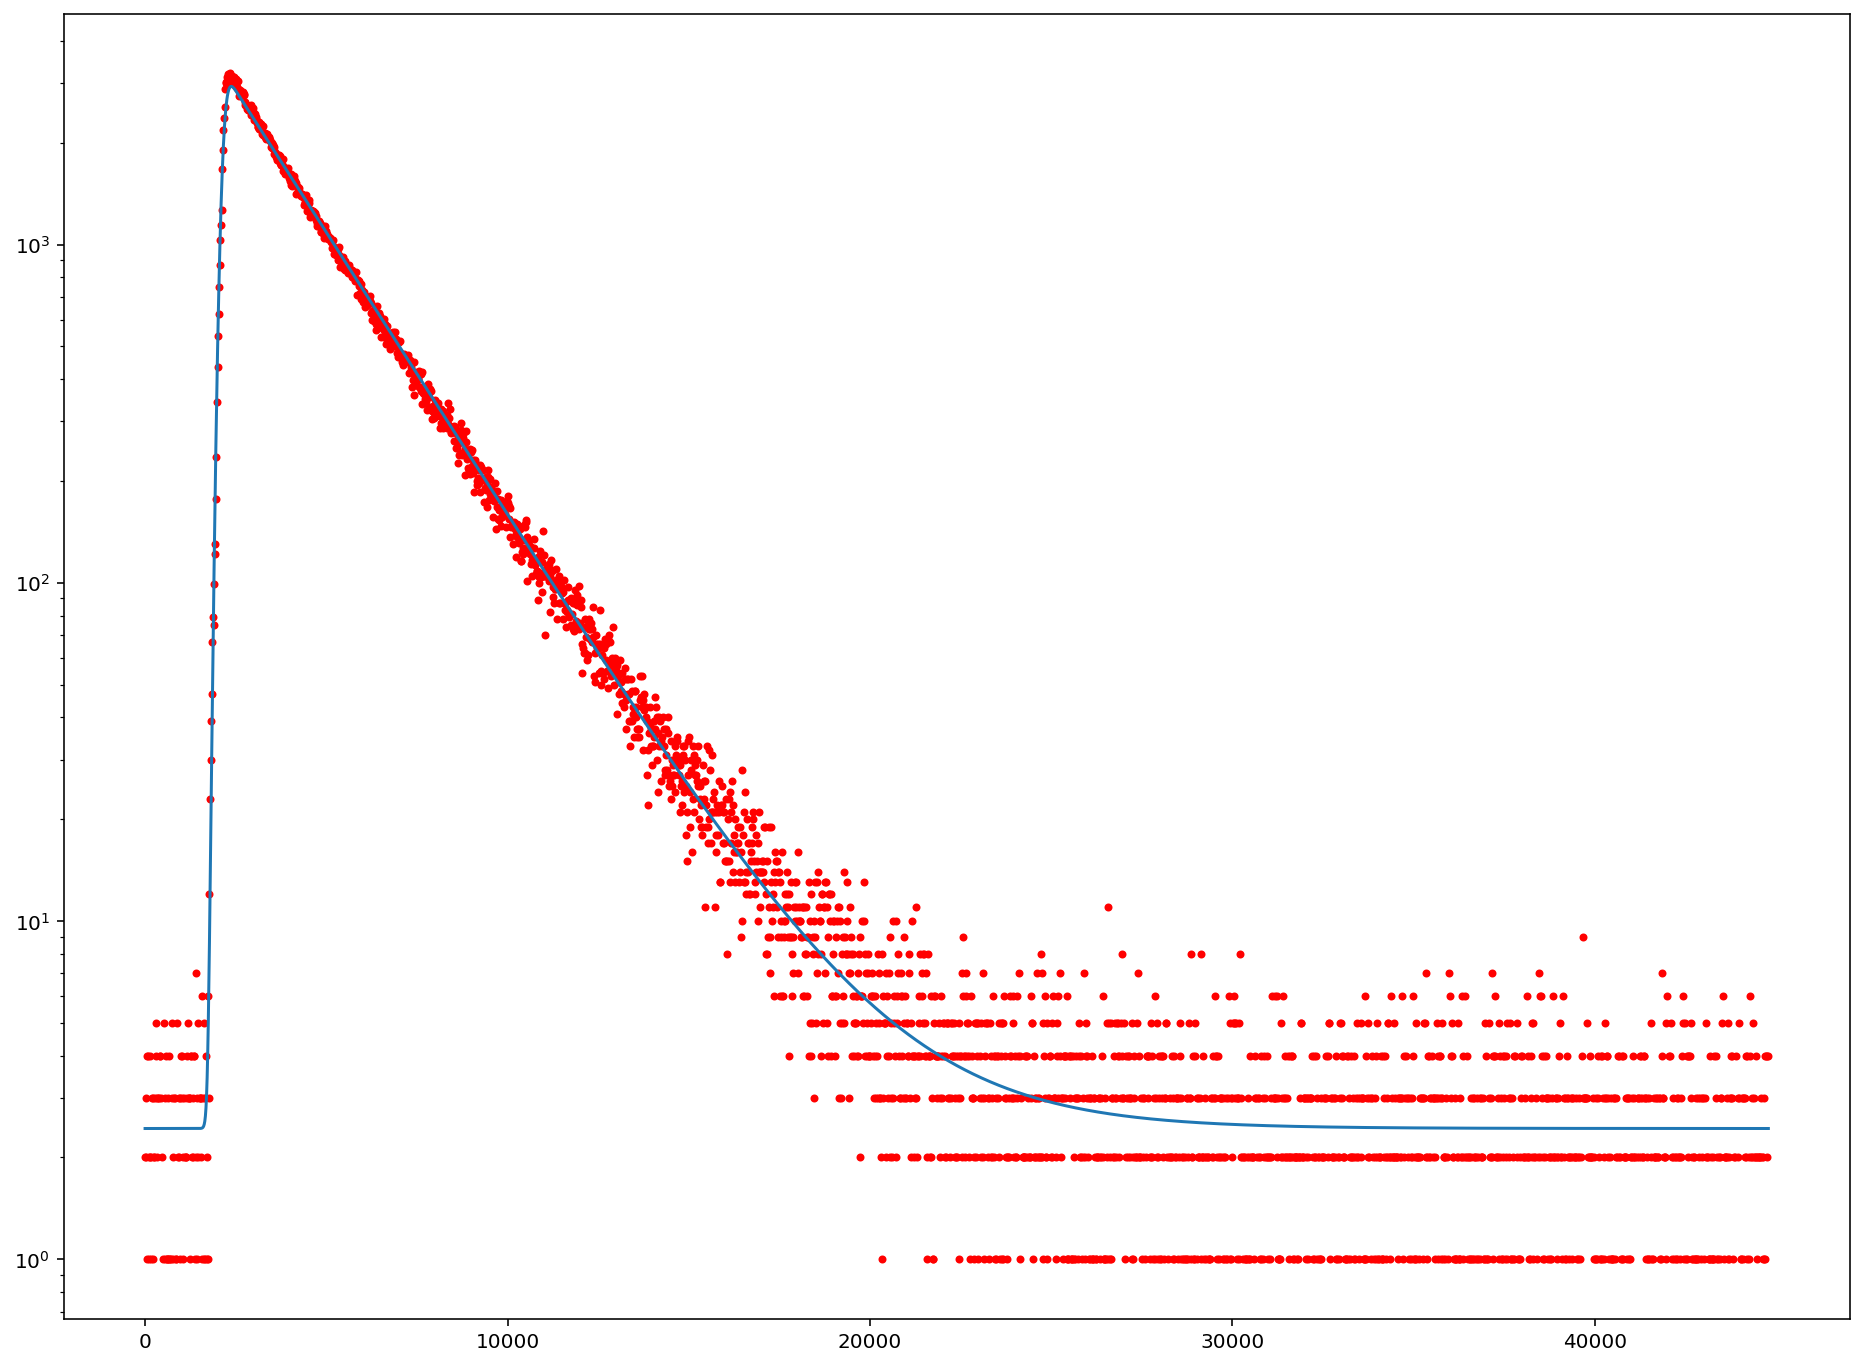

In [28]:
# Fitting by minimizing least squares
## Defining fitting function and perfoming fit
## Initial guessing and Data Fitting
para_start = (
    10, # offset
    50000, # Amplitude 1
    2500, # tau 1
    3000, # Laser mu / shift
    100, # Laser sigma
    max(fluoresceine_c1_sumDecay)*10 # Scatter
)

para_names = (
    "offset",
    "amp1",
    "tau1",
    "mu",
    "sig",
    "Scat"
)


para_bounds = (
    [1, 1000], #offset
    [1, 500000], # amp 1
    [10, 10000], #tau 1
    [10, 10000], # mu
    [20, 500], # sigma
    [0, np.infty] # scatter
)

para_opt = optimize.minimize(
    minimization_least_squares,
    para_start,
    args = (tAxis, fluoresceine_c1_sumDecay, True),
    method = 'SLSQP',
    bounds = para_bounds
)


fitted_curve = convolutedDecay(tAxis, *para_opt['x'], True)
weighted_resid = (fitted_curve - fluoresceine_c1_sumDecay)*calculateWeights(fluoresceine_c1_sumDecay)

plt.plot(tAxis, fluoresceine_c1_sumDecay, 'r.')
plt.plot(tAxis, fitted_curve)
plt.yscale('log')

print("\tInput Parameters\t Fitted Parameters")
print("---------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", para_start[i], "\t\t\t", para_opt['x'][i])


# Chi-Squared
chisq = np.sum(((fluoresceine_c1_sumDecay - fitted_curve)**2)/fitted_curve)
chisq_scipy = stats.chisquare(fluoresceine_c1_sumDecay, fitted_curve, len(para_start))

chisq_red = chisq/(len(fluoresceine_c1_sumDecay) - len(para_start))
df = len(fluoresceine_c1_sumDecay) - len(para_start)

print("\n")
print("Chi-Sq (abs. / red.):\t", chisq, "\t", chisq_red)
print("Chi-Sq (SciPy):\t\t", chisq_scipy[0], "\t", chisq_scipy[0]/df, " (p-value:", chisq_scipy[1], ")\n")

#### Minimization of Log-Likelihood Function / Poisson Deviance

$$\text{minimize} \quad D(\theta) = 2 \sum_{i = 1}^{n} \Bigg[ d(t)_i \ ln \frac{d_i(t)}{f_i(t; \theta)} - \big( d_i(t) - f_i (t; \theta) \big) \Bigg]$$

(Implemented according to Bajzer et al., 1991; Equation 8)

In [29]:
def minimize_PoissonDeviance(para_est, t, data):
    fitted = convolutedDecay(t, *para_est, fitting = True)
    
    deviance = 2 * np.nansum(
        data * np.log(data / fitted) - (data - fitted)
    )
    
    return(deviance)

/home/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log
  """
/home/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in multiply
  """


Optimization terminated successfully.    (Exit mode 0)
            Current function value: 2779.433948693524
            Iterations: 32
            Function evaluations: 278
            Gradient evaluations: 32


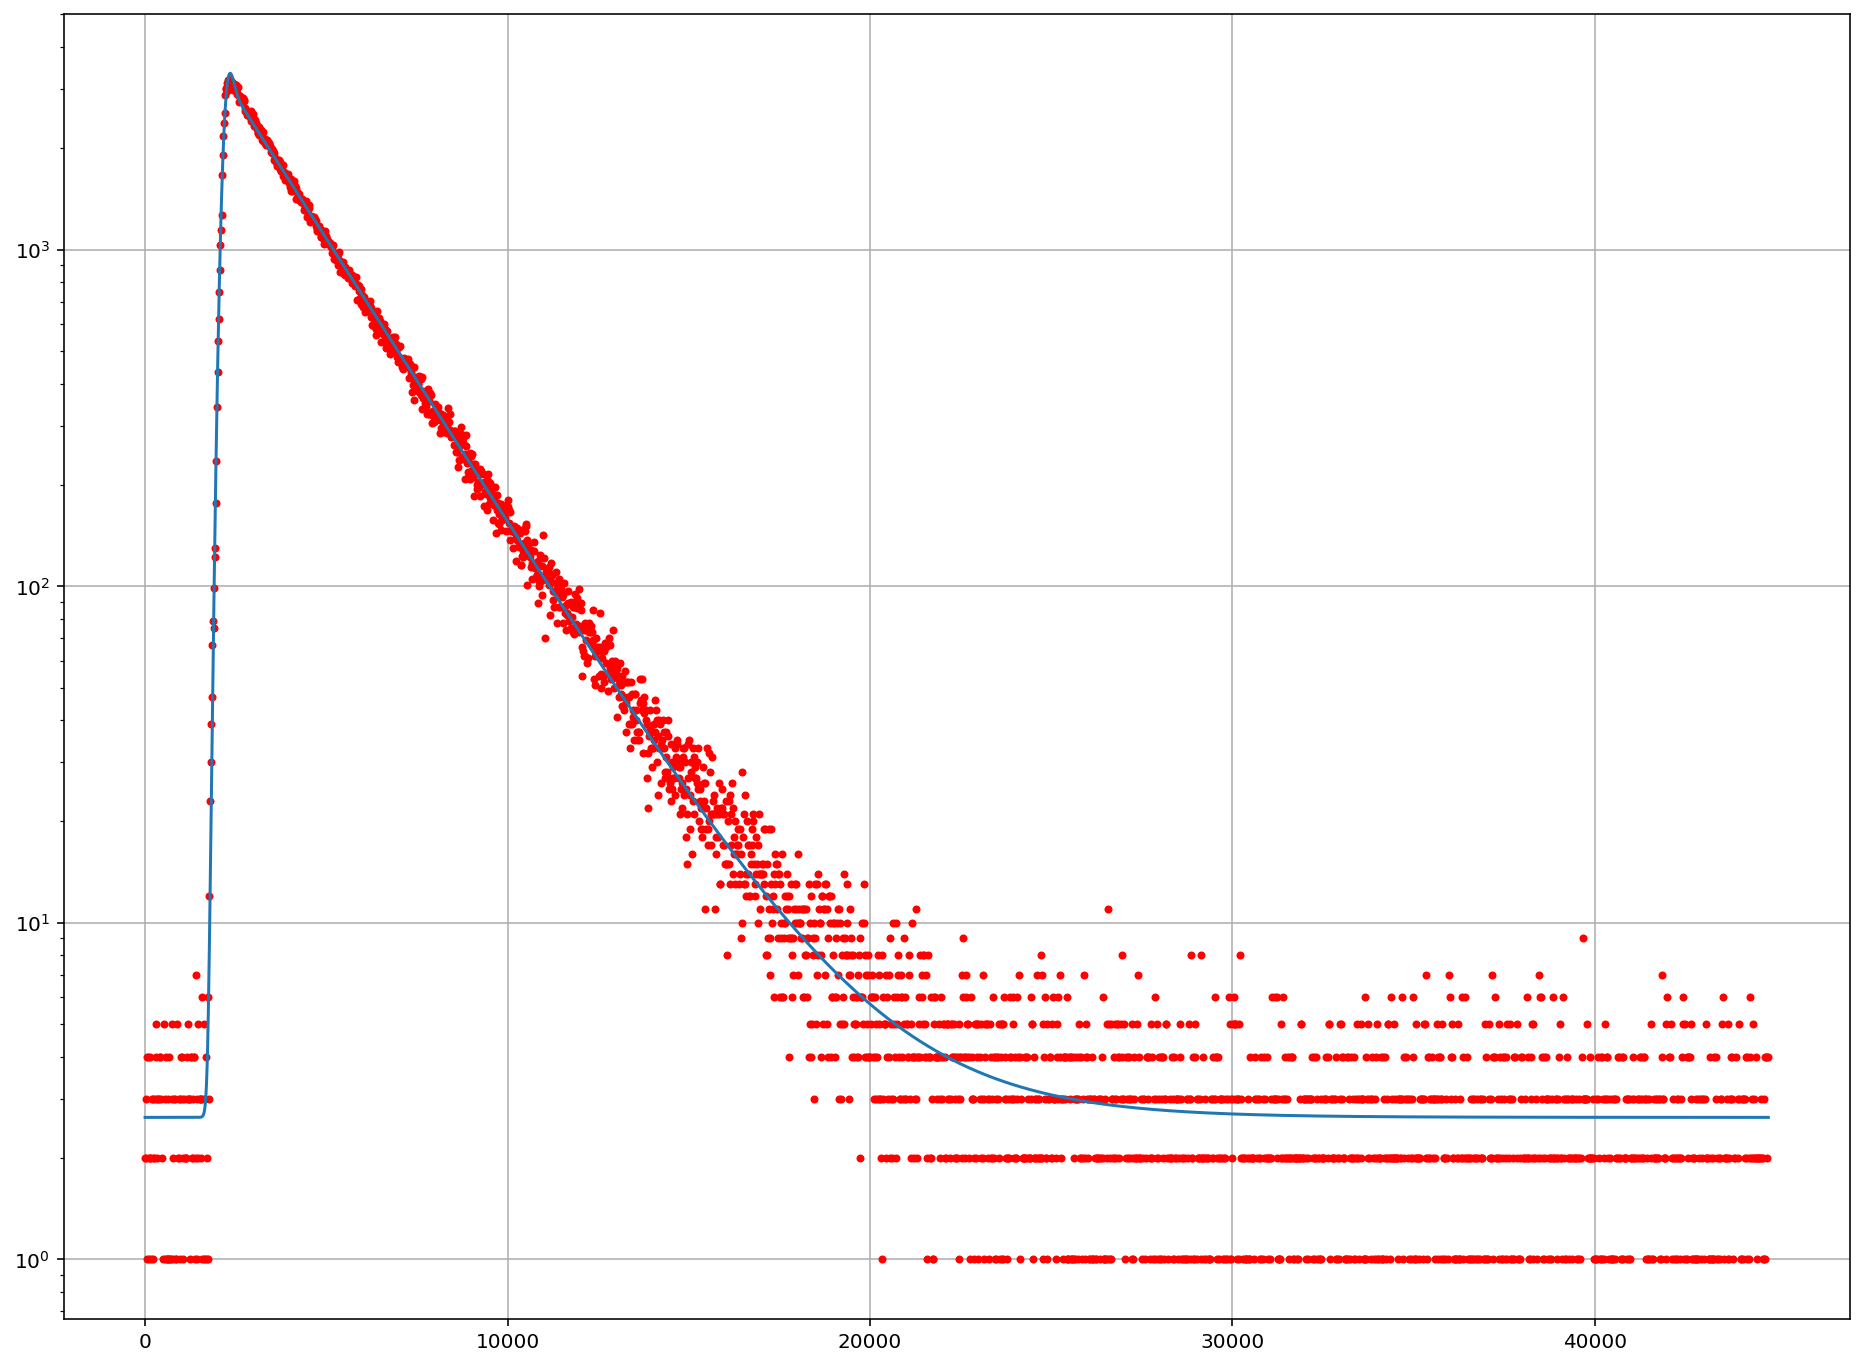

	Input Parameters	 Fitted Parameters
---------------------------------------------
offset 		 10 			 2.64053166240788
amp1 		 50000 			 35705.78960755832
tau1 		 1000 			 2563.556454348316
mu 		 3000 			 2239.550541763833
sig 		 100 			 97.51986808010552
Scat 		 320800.0 			 320672.38899956766


Chi-Sq (abs. / red.):	 3192.1482072899357 	 1.142501147920521
Chi-Sq (SciPy):		 3192.1482072899357 	 1.142501147920521  (p-value: 1.575018548519953e-07 )



In [39]:
# Fitting by minimizing Poisson deviance
## Defining fitting function and perfoming fit
## Initial guessing and Data Fitting
para_start = (
    10, # offset
    50000, # Amplitude 1
    1000, # tau 1
    3000, # Laser mu / shift
    100, # Laser sigma
    max(fluoresceine_c1_sumDecay)*100 # Scatter
)

para_names = (
    "offset",
    "amp1",
    "tau1",
    "mu",
    "sig",
    "Scat"
)


para_bounds = (
    [0, 1000], #offset
    [1, 500000], # amp 1
    [10, 10000], #tau 1
    [10, 10000], # mu
    [20, 500], # sigma
    [0, np.infty] # scatter
)

para_opt = optimize.minimize(
    minimize_PoissonDeviance,
    para_start,
    args = (tAxis, fluoresceine_c1_sumDecay),
    method = 'SLSQP',
    bounds = para_bounds,
    options = {
        'maxiter': 1000,
        'disp': True
    }
)


fitted_curve = convolutedDecay(tAxis, *para_opt['x'], True)

plt.plot(tAxis, fluoresceine_c1_sumDecay, 'r.')
plt.plot(tAxis, fitted_curve)
plt.yscale('log')
plt.grid()
#plt.savefig('../notebooks/monoFit.pdf', format = 'pdf')
plt.show()

print("\tInput Parameters\t Fitted Parameters")
print("---------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", para_start[i], "\t\t\t", para_opt['x'][i])


# Chi-Squared
chisq = np.sum(((fluoresceine_c1_sumDecay - fitted_curve)**2)/fitted_curve)
chisq_scipy = stats.chisquare(fluoresceine_c1_sumDecay, fitted_curve, len(para_start))

chisq_red = chisq/(len(fluoresceine_c1_sumDecay) - len(para_start))
df = len(fluoresceine_c1_sumDecay) - len(para_start)

print("\n")
print("Chi-Sq (abs. / red.):\t", chisq, "\t", chisq_red)
print("Chi-Sq (SciPy):\t\t", chisq_scipy[0], "\t", chisq_scipy[0]/df, " (p-value:", chisq_scipy[1], ")\n")

#### Trying MLE on Synthetic Data with Poisson Noise

In [443]:
## Trying Maximum Likelihood Estimator on Simulated Data without bounds and very bad guessing
sim_param = (
    2,
    12000,
    4201,
    4759,
    120,
    80000
)

sim_decay = convolutedDecay(tAxis, *sim_param, fitting = False)

# Fitting by minimizing Poisson deviance
## Defining fitting function and perfoming fit
## Initial guessing and Data Fitting
para_start = (
    5, # offset
    1000, # Amplitude 1
    1000, # tau 1
    1000, # Laser mu / shift
    450, # Laser sigma
    max(sim_decay)*100 # Scatter
)

para_names = (
    "offset",
    "amp1",
    "tau1",
    "mu",
    "sig",
    "Scat"
)


para_bounds = (
    [0, 1000], #offset
    [1, 500000], # amp 1
    [10, 10000], #tau 1
    [10, 10000], # mu
    [20, 500], # sigma
    [0, np.infty] # scatter
)

para_opt = optimize.minimize(
    minimize_PoissonDeviance,
    para_start,
    args = (tAxis, sim_decay),
    method = 'SLSQP',
    bounds = para_bounds,
    options = {
        'maxiter': 1000,
        'disp': True
    }
)


fitted_curve = convolutedDecay(tAxis, *para_opt['x'], True)

plt.plot(tAxis, sim_decay, 'r.')
plt.plot(tAxis, fitted_curve)
plt.yscale('log')
plt.grid()
#plt.savefig('../notebooks/monoFit.pdf', format = 'pdf')
plt.show()

print("\tInput Parameters\t Fitted Parameters")
print("---------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", sim_param[i], "\t\t\t", para_opt['x'][i])


# Chi-Squared
chisq = np.sum(((sim_decay - fitted_curve)**2)/fitted_curve)
chisq_scipy = stats.chisquare(sim_decay, fitted_curve, len(para_start))

chisq_red = chisq/(len(sim_decay) - len(para_start))
df = len(sim_decay) - len(para_start)

print("\n")
print("Chi-Sq (abs. / red.):\t", chisq, "\t", chisq_red)
print("Chi-Sq (SciPy):\t\t", chisq_scipy[0], "\t", chisq_scipy[0]/df, " (p-value:", chisq_scipy[1], ")\n")

NameError: name 'convolutedDecay' is not defined

In [442]:
print(para_opt)

NameError: name 'para_opt' is not defined